<a href="https://colab.research.google.com/github/MGuidolini/PUC-MVP/blob/main/MVP_Analise_de_Dados_e_Boas_pr%C3%A1ticas4_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Marcos Aurélio Guidolini

**Matrícula:** 4052025002325

**Dataset Calorias:** [Calorias](https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/main/calorie_dataset.csv)

# Descrição do Problema


Através de um conjunto de dados de alimentos de dados variados que consiste em informações de macronutrientes de alimentos ingeridos, em gramas, quantidade de calorias Kcal e uma classe de ingestão de calorias (Kcal): Baixo, Médio ou Alto.

O objetivo principal é identificar quanto de Kcal um indivíduo ingere por refeição e classificar em nível de calorias, Alto, Médio ou Baixo.


## Tipo de Problema

Este é um problema de **classificação supervisionada**.
Dado um conjunto de características (**Refeição:** Café da Manhã, Almoço, Lanche e Jantar; **Macronutriente:** Proteína, Carboidrato, Gordura, Fibra e Açúcar e **Calorias Totais**), se é possível prever em que classes de calorias (Baixa, Média e Alta) que cada um dos três gêneros do indivíduo (M- Masculino, F- Feminino, O- Outros) se encontram.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

**1.	Dada os três grupos de Gênero do indivíduo (M- Masculino, F- Feminino ou O- Outros) quem ingere mais calorias - Kcal?**

**2.	Em que Estados Brasileiros se consome mais Calorias - Kcal?**

**3.	Quais Macronutrientes (Carboidrato, Proteína, Gordura, fibra, açúcar) são mais consumidos pelos três Gêneros?**

**4.	Dados o Gênero do indivíduo e os alimentos ingeridos é possível identificar em que nível de Calorias eles estão divididos?**

**5.	Que faixa etárias se consome mais carboidrato?**

## Seleção de Dados

Este conjunto de dados contém dados sintéticos, porém realistas, de nutrição alimentar, projetados para tarefas de classificação para Machine learning. Cada entrada representa um alimento com sua composição de macronutrientes, calorias totais e uma classe calórica rotulada (Baixa, Média, Alta).

## Atributos do Dataset

O dataset Calorie Dataset contém 5.000 amostras, com números aleatórios de amostras para cada refeição. Possui nove atributos:


- ***Carboidrato:*** Quantidade em gramas.
- ***Proteína:*** Quantidade em gramas.
- ***Gordura:*** Quantidade em gramas.
- ***Fibra:*** Quantidade em gramas.
- ***Açúcar:*** Quantidade em gramas.
- ***Calorias:*** É o resultado do seguinte cálculo:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal

- ***Classe de Calorias*** (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Calorias.

# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Calorias, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Calorias possui 5000 instâncias (observações), com 1.248 classes de categóricas de calorias igual a **'LOW'**, 3.589 classes de categóricas de calorias igual a **'MEDIUM'** e 163 classes de categóricas de calorias igual a **'HIGH'**,  e 6 características de medição que são do tipo numérico (float).


Criando os importes necessários para utiulizar na analise dos dados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Lendo os dados do Dataset Calorias e guardando num Dataframe local

In [2]:
# Carrega arquivo csv usando Pandas usando uma URL

# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/main/calorie_dataset.csv"

# Informa o cabeçalho das colunas
colunas_Calorias = ['Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g', 'Calorias/Kcal', 'Classe_de_Calorias']


# Lê o arquivo utilizando as colunas informadas
Calorias = pd.read_csv(url, names=colunas_Calorias, skiprows=1, delimiter=',')

# Pega apenas os dados do dataset e guardando em um array
array = Calorias.values


# Separa o array em variáveis preditoras (X) e variável target (Y)
X = array[:,0:8]
Y = array[:,0:8]

dafr_Calorias = pd.DataFrame(data=Calorias, columns=colunas_Calorias)

# Verificar e imprimir na tela o total de instâncias
print(f"Total de instâncias: {len(Calorias)}")
print("\nTipos de dados por coluna:")
print(dafr_Calorias.info())

Total de instâncias: 5000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Carboidrato/g       5000 non-null   float64
 1   Proteina/g          5000 non-null   float64
 2   Gordura/g           5000 non-null   float64
 3   Fibra/g             5000 non-null   float64
 4   Acucar/g            5000 non-null   float64
 5   Calorias/Kcal       5000 non-null   float64
 6   Classe_de_Calorias  5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
None


Verificar se tem valores nulos na base de dados do Datafreme.

In [3]:
# Verificar se tem valor nulo do Dataframe
print("Valores nulos no dataset dafr_Calorias:")
dafr_Calorias.isnull().sum()

Valores nulos no dataset dafr_Calorias:


,0
Carboidrato/g,0
Proteina/g,0
Gordura/g,0
Fibra/g,0
Acucar/g,0
Calorias/Kcal,0
Classe_de_Calorias,0


Distibuição de Classes de Calorias (LOW, MEDIUM, HIGH)

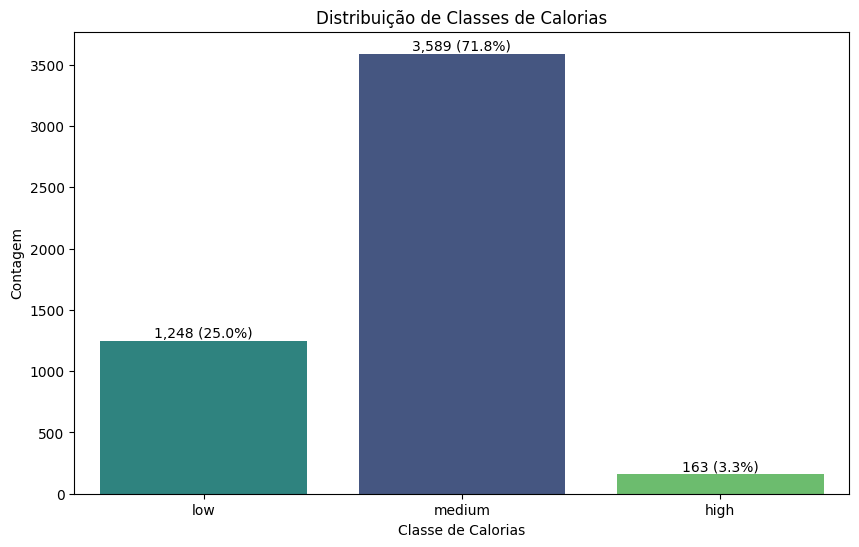

In [4]:
plt.figure(figsize=(10, 6))
# gráfico de barras simples
ax = sns.countplot(x='Classe_de_Calorias', data=dafr_Calorias, hue='Classe_de_Calorias', palette='viridis', legend=False, order=['low', 'medium', 'high'])
plt.title('Distribuição de Classes de Calorias')
plt.xlabel('Classe de Calorias')
plt.ylabel('Contagem')

# Calcular as contagens e porcentagens
total = len(dafr_Calorias)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.show()

Observei que a contagem de Classe de Calorias acima, classificadas como 'low' (baixa), 'medium' (média) ou 'high' (alta). foi identificado que as Classes de Calorias classificadas como 'high' (alta) é maior que as outras com 71,3% de todas contagem, seguida pela 'medium' (média) com 25% a low (baixa) com a menor porcentagem 3,3%. Evidenciando que é um datasets com uma distribuição não uniforme entre as classes, então dos dados estão desbalanceados.

Balanceando as Classe de Calorias do Dataset Calorias

In [5]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Características separadas (X) e alvo (y) do DataFrame dafr_Refeicao
X = dafr_Calorias.drop('Classe_de_Calorias', axis=1)
y = dafr_Calorias['Classe_de_Calorias']

print("Distribuição original da classe 'Classe_de_Calorias':")
print(y.value_counts())

# Determine a quantidade de pessoas da classe majoritária. ('medium')
# Essa será nossa meta de contagem para o balanceamento.
target_class_count = y.value_counts()['medium']

# Defina a estratégia de amostragem para RandomOverSampler:
# Sobrepor as classes 'low' e 'high' para corresponder à contagem da classe 'medium'.
# 'medium' itself is not included in the strategy, so it will remain at its original count.
sampling_strategy = {
    'low': target_class_count,
    'high': target_class_count
}

# Inicializar RandomOverSampler
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)

# Aplica sobreposição ao conjunto de dados.
X_resampled, y_resampled = ros.fit_resample(X, y)

print("\nDistribuição da classe após o balanceamento (Oversampling):")
print(pd.Series(y_resampled).value_counts())

# Combine as características reamostradas e o alvo em um novo DataFrame.
dafr_Calorias_balanced = pd.DataFrame(X_resampled, columns=X.columns)
dafr_Calorias_balanced['Classe_de_Calorias'] = y_resampled

print("\nNovo DataFrame balanceado 'dafr_Refeicao_balanced' (primeiras 5 linhas):")
display(dafr_Calorias_balanced.head())

print("\nDistribuição final de classes no novo DataFrame balanceado:")
print(dafr_Calorias_balanced['Classe_de_Calorias'].value_counts())

Distribuição original da classe 'Classe_de_Calorias':
Classe_de_Calorias
medium    3589
low       1248
high       163
Name: count, dtype: int64

Distribuição da classe após o balanceamento (Oversampling):
Classe_de_Calorias
medium    3589
low       3589
high      3589
Name: count, dtype: int64

Novo DataFrame balanceado 'dafr_Refeicao_balanced' (primeiras 5 linhas):


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias
0,22.5,65.2,13.7,9.9,26.7,479.0,medium
1,15.9,20.7,16.8,7.6,15.0,316.0,low
2,28.3,62.4,14.5,10.8,15.3,524.0,medium
3,23.3,18.6,7.9,17.0,0.2,250.0,low
4,30.8,55.1,31.9,12.5,7.2,602.0,medium



Distribuição final de classes no novo DataFrame balanceado:
Classe_de_Calorias
medium    3589
low       3589
high      3589
Name: count, dtype: int64


Com o balanceamento de Classes de Calorias a contagem de instância subiu para 10.767, ficando todas as classes de calorias **'low'** (*baixa*), **'medium'** (*média*) e **'high'** (*alta*) com a mesma quantidade de instâncias (***3.589***).

Verificar se tem valores nulos na base de dados do Datafreme depois do balanceamento.

In [6]:
# Verificar se tem valor nulo do Dataframe
print("Valores nulos no dataset dafr_Calorias:")
dafr_Calorias.isnull().sum()

Valores nulos no dataset dafr_Calorias:


,0
Carboidrato/g,0
Proteina/g,0
Gordura/g,0
Fibra/g,0
Acucar/g,0
Calorias/Kcal,0
Classe_de_Calorias,0


Distibuição de Classes de Calorias (**LOW**, **MEDIUM**, **HIGH**), Balanceado.

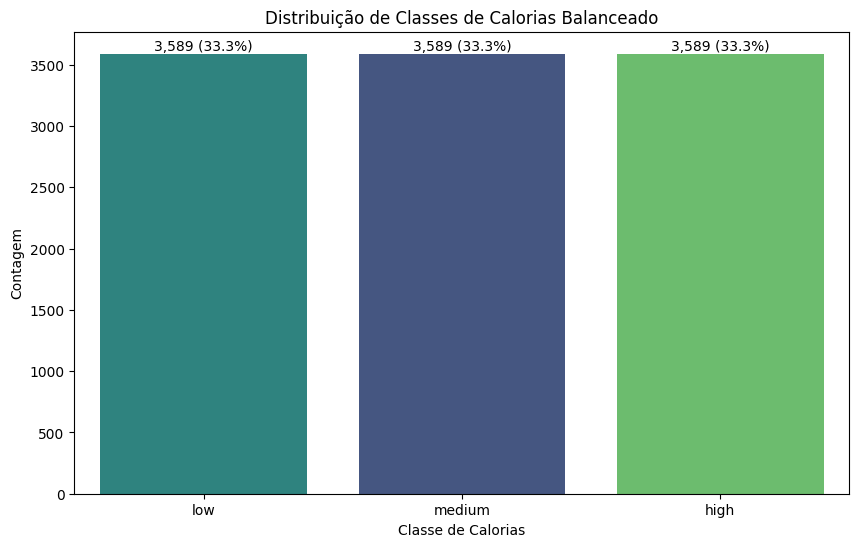

In [8]:
plt.figure(figsize=(10, 6))
# gráfico de barras simples
ax = sns.countplot(x='Classe_de_Calorias', data=dafr_Calorias_balanced, hue='Classe_de_Calorias', palette='viridis', legend=False, order=['low', 'medium', 'high'])
plt.title('Distribuição de Classes de Calorias Balanceado')
plt.xlabel('Classe de Calorias')
plt.ylabel('Contagem')

# Calcular as contagens e porcentagens
total = len(dafr_Calorias_balanced)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.show()

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis do dataset Desbalanceado.

In [9]:
# estatísticas descritivas básicas do dataset
dafr_Calorias.describe()

,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,25.076720,49.850420,20.105280,8.103620,15.088980,480.455800
std,9.907564,20.071407,7.933298,3.923217,9.298863,117.948845
min,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000
25%,18.400000,36.300000,14.700000,5.300000,8.000000,400.000000
50%,25.100000,49.650000,20.100000,8.100000,14.900000,480.000000
75%,31.700000,63.525000,25.400000,10.800000,21.500000,561.250000
max,64.300000,120.600000,47.400000,25.900000,51.100000,975.000000


Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis do dataset balanceado.

In [ ]:
# estatísticas descritivas básicas do dataset balanceado
dafr_Calorias_balanced.describe()

,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal
count,10767.000000,10767.000000,10767.000000,10767.000000,10767.000000,10767.000000
mean,26.379103,56.043011,22.204746,8.086979,15.825541,531.147766
std,10.185445,25.590144,9.442152,3.799628,9.622279,178.756017
min,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000
25%,19.700000,36.600000,15.200000,5.400000,8.800000,376.000000
50%,26.800000,55.400000,22.500000,8.100000,15.300000,512.000000
75%,33.500000,76.100000,29.300000,10.600000,22.500000,714.000000
max,64.300000,120.600000,47.400000,25.900000,51.100000,975.000000


# estatísticas descritivas básicas do dataset


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

Média dos atributos Desbalanceados

In [10]:
# média dos atributos numéricos do dataset
dafr_Calorias.describe().loc['mean']

,mean
Carboidrato/g,25.07672
Proteina/g,49.85042
Gordura/g,20.10528
Fibra/g,8.10362
Acucar/g,15.08898
Calorias/Kcal,480.45580


Gráfico de Barras com informações de distribuição das médias dos atrubutos numéricos dos dados Desbalanceados.

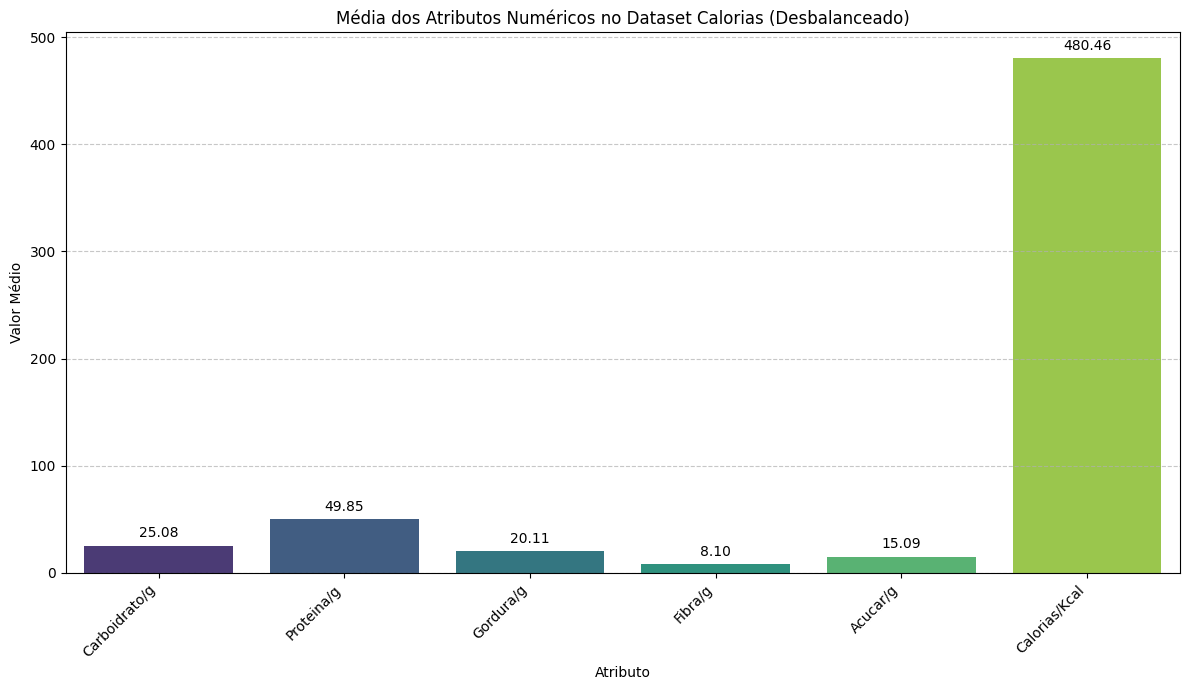

DataFrame 'dafr_Calorias' com a linha da média adicionada:


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias
4996,18.20000,67.00000,25.10000,6.40000,13.90000,542.0000,medium
4997,14.20000,49.80000,28.90000,2.10000,0.10000,519.0000,medium
4998,22.00000,20.50000,28.30000,13.90000,13.40000,444.0000,medium
4999,33.60000,36.60000,17.60000,3.70000,27.50000,433.0000,medium
5000,25.07672,49.85042,20.10528,8.10362,15.08898,480.4558,Média Geral


In [11]:
# Obtendo as médias dos atributos numéricos do dataset
mean_values = dafr_Calorias.describe().loc['mean']

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='viridis', hue=mean_values.index, legend=False)
plt.title('Média dos Atributos Numéricos no Dataset Calorias (Desbalanceado)')
plt.xlabel('Atributo')
plt.ylabel('Valor Médio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Inserir valores da média nas colunas do gráfico
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Criar uma Series para a linha da média, correspondendo às colunas de dafr_Calorias
mean_row_df = mean_values.to_frame().T
mean_row_df['Classe_de_Calorias'] = 'Média Geral' # Rótulo para a nova linha

# Garantir que a ordem das colunas corresponda a dafr_Calorias para uma concatenação limpa
mean_row_df = mean_row_df[dafr_Calorias.columns]

# Concatenar a nova linha ao dafr_Calorias
dafr_Calorias_com_medias = pd.concat([dafr_Calorias, mean_row_df], ignore_index=True)

print("DataFrame 'dafr_Calorias' com a linha da média adicionada:")
display(dafr_Calorias_com_medias.tail())

Média dos atributos Balanceados

In [13]:
# média dos atributos numéricos do dataset Balanceado
dafr_Calorias_balanced.describe().loc['mean']

,mean
Carboidrato/g,26.379103
Proteina/g,56.043011
Gordura/g,22.204746
Fibra/g,8.086979
Acucar/g,15.825541
Calorias/Kcal,531.147766


Gráfico de Barras com informações de distribuição das médias dos atrubutos numéricos dos dados Balanceados.

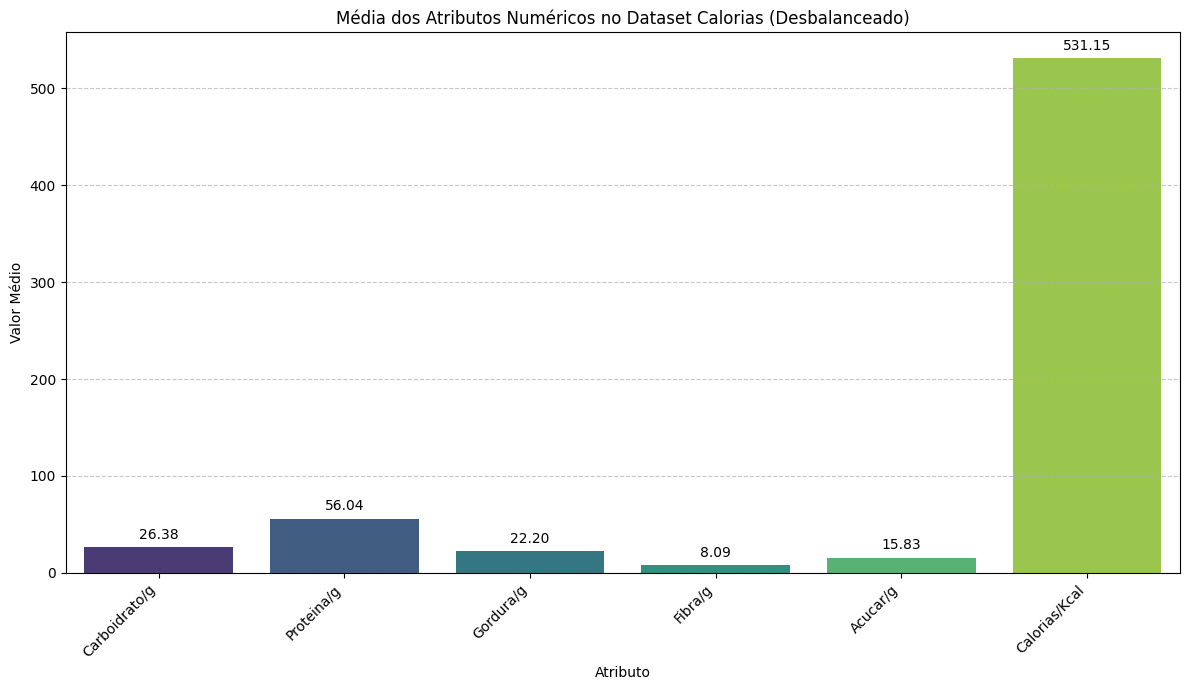

DataFrame 'dafr_Calorias' com a linha da média adicionada:


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias
10763,20.600000,25.100000,12.700000,9.400000,9.500000,237.000000,low
10764,14.900000,34.300000,22.500000,8.100000,31.100000,377.000000,low
10765,30.000000,37.700000,5.700000,8.900000,7.300000,385.000000,low
10766,20.900000,13.800000,18.600000,6.000000,28.700000,288.000000,low
10767,26.379103,56.043011,22.204746,8.086979,15.825541,531.147766,Média Geral


In [14]:
# Obtendo as médias dos atributos numéricos do dataset
mean_values = dafr_Calorias_balanced.describe().loc['mean']

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='viridis', hue=mean_values.index, legend=False)
plt.title('Média dos Atributos Numéricos no Dataset Calorias (Desbalanceado)')
plt.xlabel('Atributo')
plt.ylabel('Valor Médio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Inserir valores da média nas colunas do gráfico
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

# Criar uma Series para a linha da média, correspondendo às colunas de dafr_Calorias
mean_row_df = mean_values.to_frame().T
mean_row_df['Classe_de_Calorias'] = 'Média Geral' # Rótulo para a nova linha

# Garantir que a ordem das colunas corresponda a dafr_Calorias para uma concatenação limpa
mean_row_df = mean_row_df[dafr_Calorias_balanced.columns]

# Concatenar a nova linha ao dafr_Calorias
dafr_Calorias_com_medias = pd.concat([dafr_Calorias_balanced, mean_row_df], ignore_index=True)

print("DataFrame 'dafr_Calorias' com a linha da média adicionada:")
display(dafr_Calorias_com_medias.tail())

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

Desvio Padrão dos atributos Desbalanceados

In [15]:
# desvio padrão dos atributos numéricos do dataset
dafr_Calorias.describe().loc['std']

,std
Carboidrato/g,9.907564
Proteina/g,20.071407
Gordura/g,7.933298
Fibra/g,3.923217
Acucar/g,9.298863
Calorias/Kcal,117.948845


Gráfico de Barras com informações de distribuição da Desvio Padrão dos atrubutos numéricos dos dados Desbalanceados.

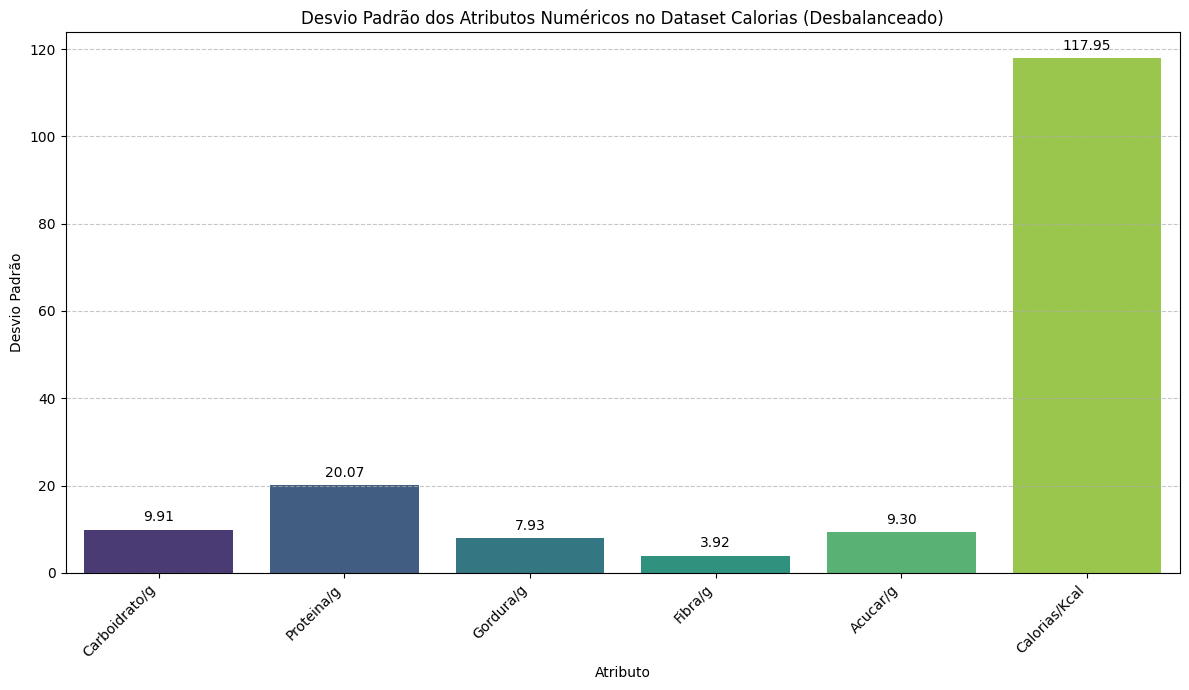

In [16]:
# Gráfico de Barras com informações de distribuição do desvio padrão dos atributos numéricos do dataset

# Obtendo os desvios padrão dos atributos numéricos do dataset
std_values = dafr_Calorias.describe().loc['std']

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=std_values.index, y=std_values.values, palette='viridis', hue=std_values.index, legend=False)
plt.title('Desvio Padrão dos Atributos Numéricos no Dataset Calorias (Desbalanceado)')
plt.xlabel('Atributo')
plt.ylabel('Desvio Padrão')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Inserir valores do desvio padrão nas colunas do gráfico
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

Desvio Padrão dos atributos Balanceado

In [17]:
# desvio padrão dos atributos numéricos do dataset
dafr_Calorias_balanced.describe().loc['std']

,std
Carboidrato/g,10.185445
Proteina/g,25.590144
Gordura/g,9.442152
Fibra/g,3.799628
Acucar/g,9.622279
Calorias/Kcal,178.756017


Gráfico de Barras com informações de distribuição da Desvio Padrão dos atrubutos numéricos dos dados Balanceados.

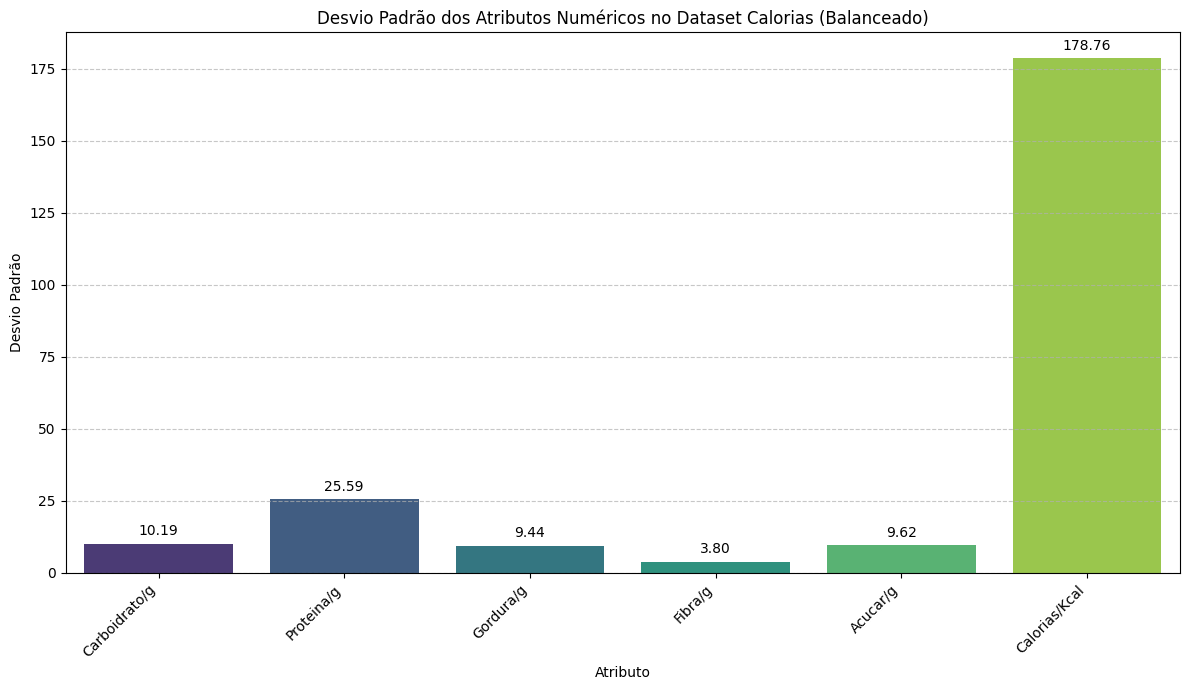

In [18]:
# Gráfico de Barras com informações de distribuição do desvio padrão dos atributos numéricos do dataset

# Obtendo os desvios padrão dos atributos numéricos do dataset
std_values = dafr_Calorias_balanced.describe().loc['std']

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=std_values.index, y=std_values.values, palette='viridis', hue=std_values.index, legend=False)
plt.title('Desvio Padrão dos Atributos Numéricos no Dataset Calorias (Balanceado)')
plt.xlabel('Atributo')
plt.ylabel('Desvio Padrão')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Inserir valores do desvio padrão nas colunas do gráfico
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *Quantidade de Calorias por Classe de Calorias '**Low**' - Desbalanceado*


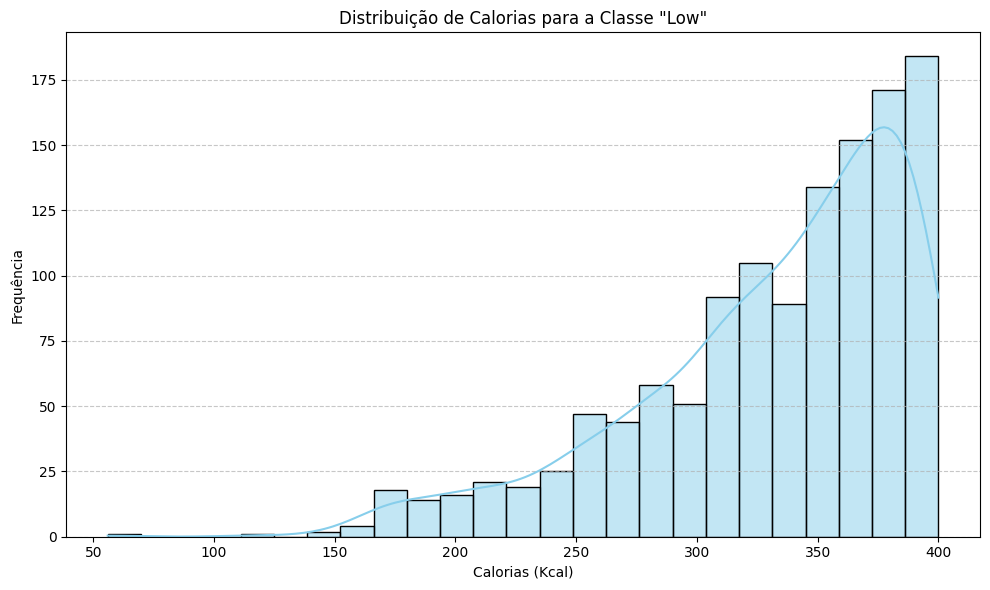

In [19]:
# Filtrar o DataFrame balanceado para a classe 'low'
df_low_calories = dafr_Calorias[dafr_Calorias['Classe_de_Calorias'] == 'low']

plt.figure(figsize=(10, 6))
sns.histplot(df_low_calories['Calorias/Kcal'], kde=True, color='skyblue')
plt.title('Distribuição de Calorias para a Classe "Low"')
plt.xlabel('Calorias (Kcal)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### *Quantidade de Calorias por Classe de Calorias '**Medium**' - Desbalanceado*

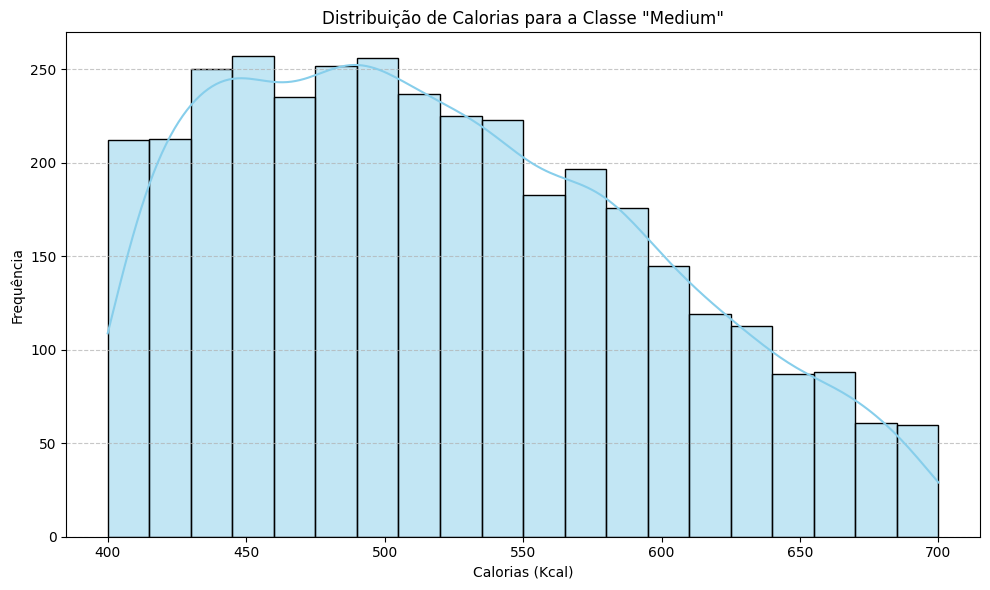

In [20]:
# Filtrar o DataFrame balanceado para a classe 'medium'
df_medium_calories = dafr_Calorias[dafr_Calorias['Classe_de_Calorias'] == 'medium']

plt.figure(figsize=(10, 6))
sns.histplot(df_medium_calories['Calorias/Kcal'], kde=True, color='skyblue')
plt.title('Distribuição de Calorias para a Classe "Medium"')
plt.xlabel('Calorias (Kcal)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### *Quantidade de Calorias por Classe de Calorias '**High**'* - Desbalanceado

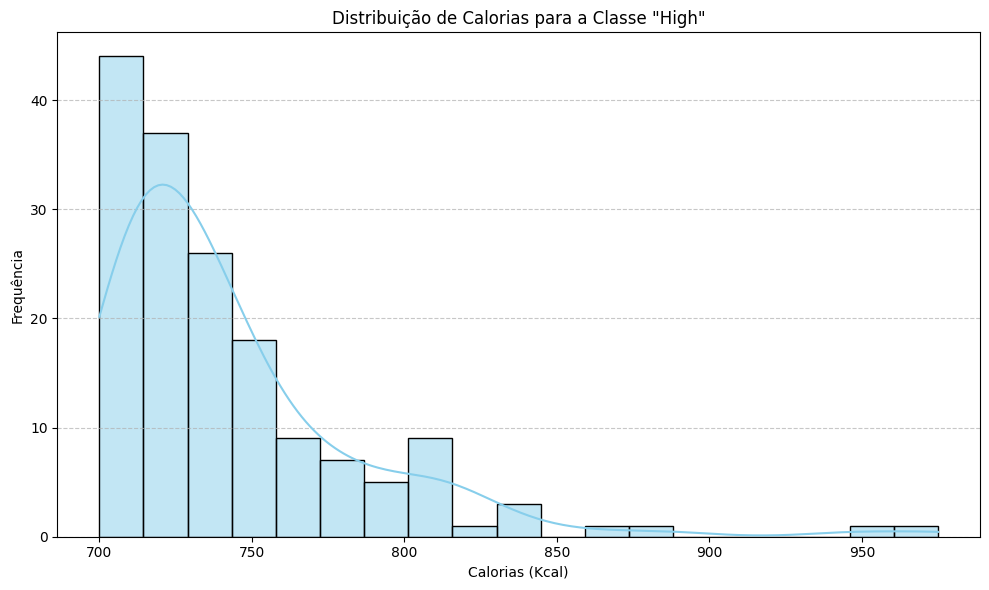

In [21]:
# Filtrar o DataFrame balanceado para a classe 'high'
df_medium_calories = dafr_Calorias[dafr_Calorias['Classe_de_Calorias'] == 'high']

plt.figure(figsize=(10, 6))
sns.histplot(df_medium_calories['Calorias/Kcal'], kde=True, color='skyblue')
plt.title('Distribuição de Calorias para a Classe "High"')
plt.xlabel('Calorias (Kcal)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### *Quantidade de Calorias por Classe de Calorias '**Low**' - Balanceado*

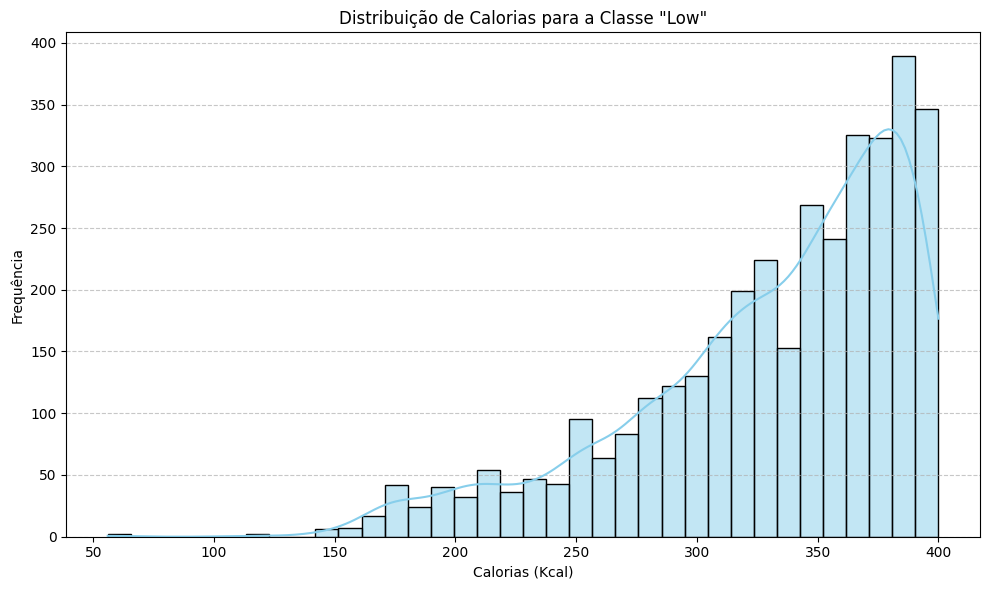

In [22]:
# Filtrar o DataFrame balanceado para a classe 'low'
df_low_calories = dafr_Calorias_balanced[dafr_Calorias_balanced['Classe_de_Calorias'] == 'low']

plt.figure(figsize=(10, 6))
sns.histplot(df_low_calories['Calorias/Kcal'], kde=True, color='skyblue')
plt.title('Distribuição de Calorias para a Classe "Low"')
plt.xlabel('Calorias (Kcal)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### *Quantidade de Calorias por Classe de Calorias '**Medium**' - Balanceado*

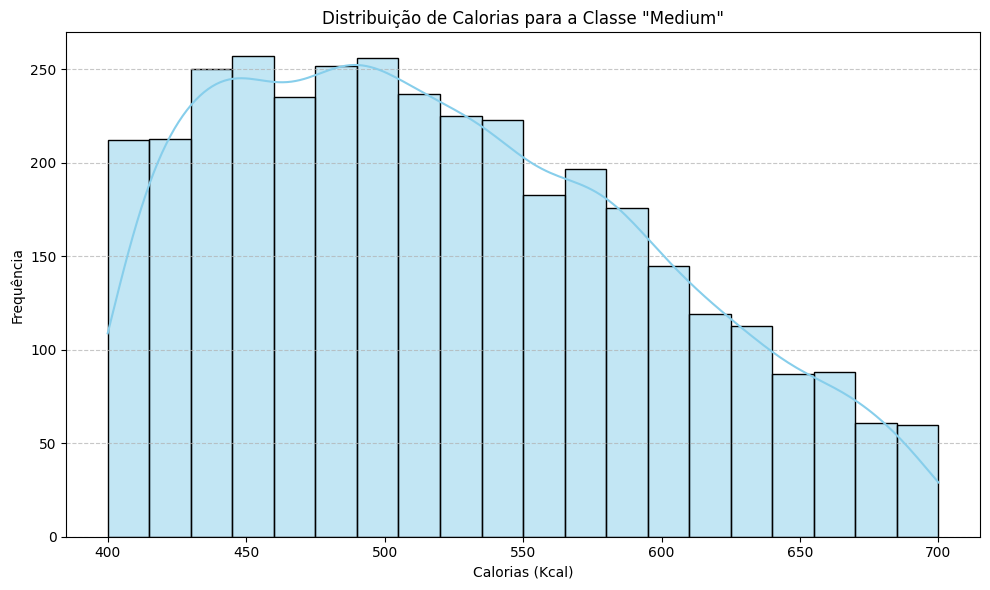

In [23]:
# Filtrar o DataFrame balanceado para a classe 'medium'
df_medium_calories = dafr_Calorias_balanced[dafr_Calorias_balanced['Classe_de_Calorias'] == 'medium']

plt.figure(figsize=(10, 6))
sns.histplot(df_medium_calories['Calorias/Kcal'], kde=True, color='skyblue')
plt.title('Distribuição de Calorias para a Classe "Medium"')
plt.xlabel('Calorias (Kcal)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### *Quantidade de Calorias por Classe de Calorias '**High**'* - Balanceado

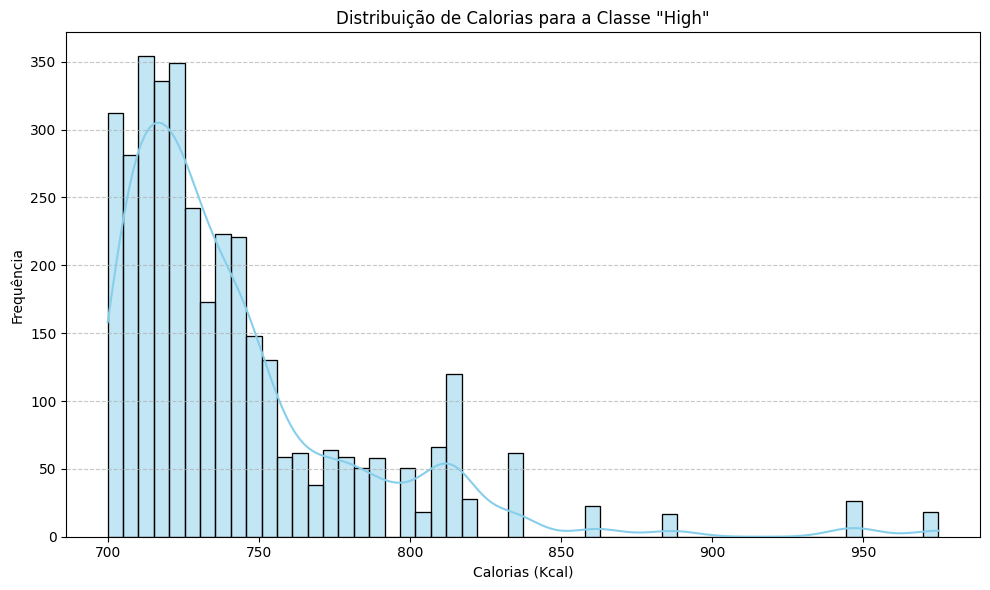

In [24]:
# Filtrar o DataFrame balanceado para a classe 'high'
df_medium_calories = dafr_Calorias_balanced[dafr_Calorias_balanced['Classe_de_Calorias'] == 'high']

plt.figure(figsize=(10, 6))
sns.histplot(df_medium_calories['Calorias/Kcal'], kde=True, color='skyblue')
plt.title('Distribuição de Calorias para a Classe "High"')
plt.xlabel('Calorias (Kcal)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

O histograma mostra a distribuição do comprimento da sépala. A curva de densidade estimada (KDE) nos indica que a distribuição parece bimodal ou multimodal, indicando que as espécies podem ter comprimentos de sépalas diferentes.

## Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por Classe de Calorias. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Classe de calorias **Low**, **Medium** e **Hight**, além de visualizar suas distribuições por meio de boxplots.


Estatísticas descritivas agrupadas por espécie - Desbalanceado

In [31]:
# Estatísticas descritivas agrupadas por Classe de Calorias
dafr_Calorias.groupby('Classe_de_Calorias').describe()

Carboidrato/g                                          \
                           count       mean       std  min     25%   50%   
Classe_de_Calorias                                                         
high                       163.0  31.935583  8.595546  9.4  25.450  32.0   
low                       1248.0  21.020994  9.421050  0.0  14.475  21.3   
medium                    3589.0  26.175508  9.670193  0.0  19.500  26.3   

                                 Proteina/g             ... Acucar/g        \
                       75%   max      count       mean  ...      75%   max   
Classe_de_Calorias                                      ...                  
high                37.200  56.4      163.0  80.871166  ...    23.75  44.3   
low                 27.325  56.1     1248.0  32.467708  ...    21.40  51.1   
medium              32.600  64.3     3589.0  54.486041  ...    21.30  51.0   

                   Calorias/Kcal                                              \
                           count        mean        std    min    25%    50%   
Classe_de_Calorias                                                             
high                       163.0  742.638037  43.325757  700.0  713.5  729.0   
low                       1248.0  331.254006  57.040444   56.0  302.0  347.0   
medium                    3589.0  520.430203  75.519102  400.0  457.0  512.0   

                                  
                      75%    max  
Classe_de_Calorias                
high                753.5  975.0  
low                 377.0  400.0  
medium              576.0  700.0  

[3 rows x 48 columns]

Estatísticas descritivas agrupadas por espécie - Balanceado

In [32]:
# Estatísticas descritivas agrupadas por Classe de Calorias
dafr_Calorias_balanced.groupby('Classe_de_Calorias').describe()

Carboidrato/g                                              \
                           count       mean       std  min   25%   50%   75%   
Classe_de_Calorias                                                             
high                      3589.0  31.926219  8.428001  9.4  25.7  31.7  37.2   
low                       3589.0  21.035581  9.346773  0.0  14.6  21.2  27.3   
medium                    3589.0  26.175508  9.670193  0.0  19.5  26.3  32.6   

                         Proteina/g             ... Acucar/g        \
                     max      count       mean  ...      75%   max   
Classe_de_Calorias                              ...                  
high                56.4     3589.0  81.310226  ...     23.7  44.3   
low                 56.1     3589.0  32.332767  ...     21.2  51.1   
medium              64.3     3589.0  54.486041  ...     21.3  51.0   

                   Calorias/Kcal                                              \
                           count        mean        std    min    25%    50%   
Classe_de_Calorias                                                             
high                      3589.0  742.511284  42.808604  700.0  714.0  728.0   
low                       3589.0  330.501811  57.195589   56.0  302.0  347.0   
medium                    3589.0  520.430203  75.519102  400.0  457.0  512.0   

                                  
                      75%    max  
Classe_de_Calorias                
high                753.0  975.0  
low                 376.0  400.0  
medium              576.0  700.0  

[3 rows x 48 columns]

### Classe de Calorias 'Low' para todos atributos numéricos - Desbalanceado


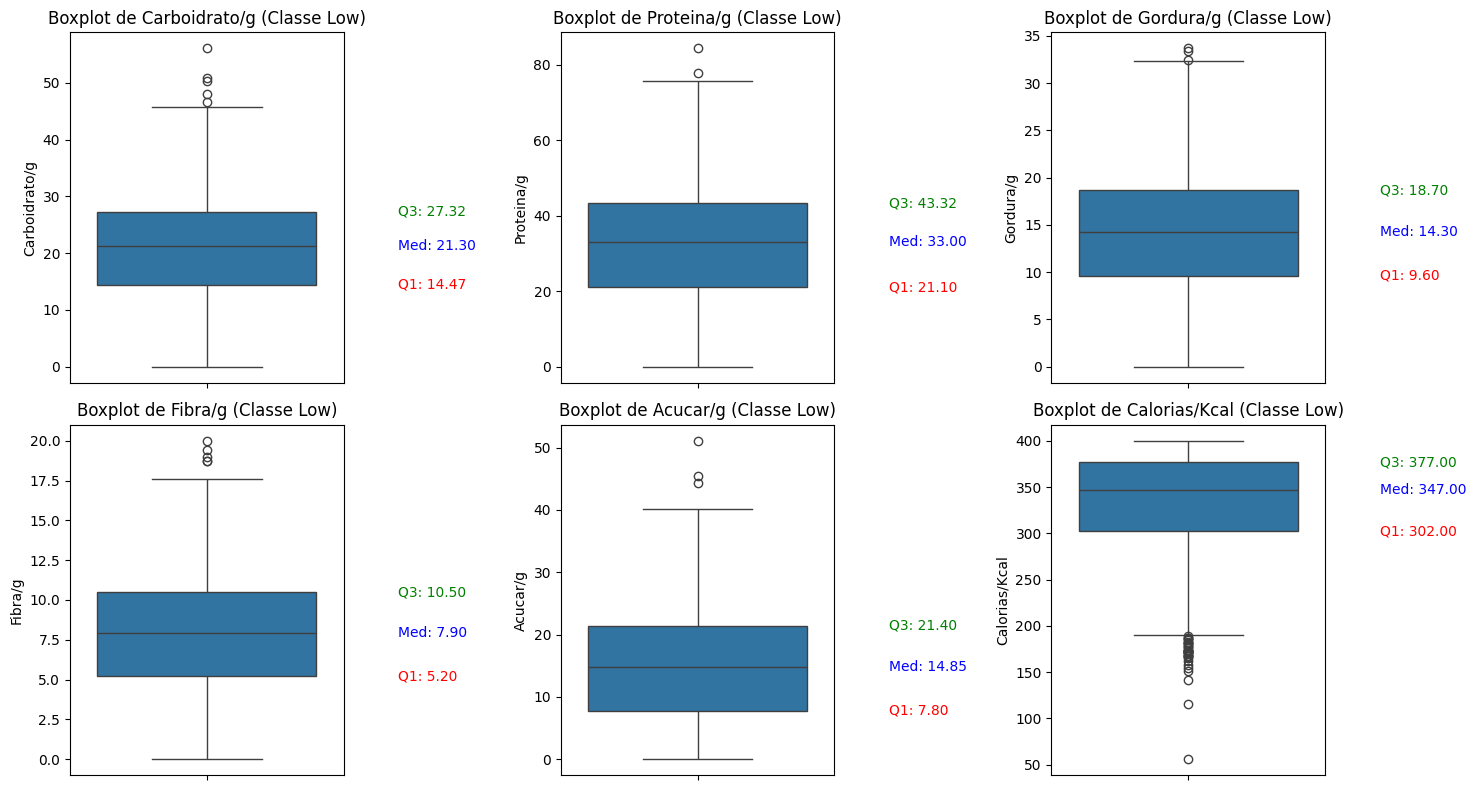


Estatísticas descritivas para a Classe de Calorias 'Low':


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal
count,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000
mean,21.020994,32.467708,14.114663,7.872837,15.163061,331.254006
std,9.421050,15.962803,6.576781,3.798705,9.520974,57.040444
min,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000
25%,14.475000,21.100000,9.600000,5.200000,7.800000,302.000000
50%,21.300000,33.000000,14.300000,7.900000,14.850000,347.000000
75%,27.325000,43.325000,18.700000,10.500000,21.400000,377.000000
max,56.100000,84.400000,33.700000,20.000000,51.100000,400.000000


In [36]:
df_low_calories = dafr_Calorias[dafr_Calorias['Classe_de_Calorias'] == 'low']

# Criar boxplots para todas as características numéricas na classe 'low'
plt.figure(figsize=(15, 8))
num_cols = df_low_calories.select_dtypes(include=np.number).columns

for i, column in enumerate(num_cols):
    # Ajustar o layout com base no número de colunas numéricas
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_low_calories[column])
    plt.title(f'Boxplot de {column} (Classe Low)')
    plt.ylabel(column)

    # Calcula Q1, Mediana e Q3.
    Q1 = df_low_calories[column].quantile(0.25)
    Median = df_low_calories[column].median()
    Q3 = df_low_calories[column].quantile(0.75)

    # Texto Q1, Mediana e Q3 no gráfico.
    plt.text(0.7, Q1, f'Q1: {Q1:.2f}', verticalalignment='center', color='red', fontsize=10)
    plt.text(0.7, Median, f'Med: {Median:.2f}', verticalalignment='center', color='blue', fontsize=10)
    plt.text(0.7, Q3, f'Q3: {Q3:.2f}', verticalalignment='center', color='green', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEstatísticas descritivas para a Classe de Calorias 'Low':")
display(df_low_calories.describe())

### Classe de Calorias 'Medium' para todos atributos numéricos - Desbalanceado

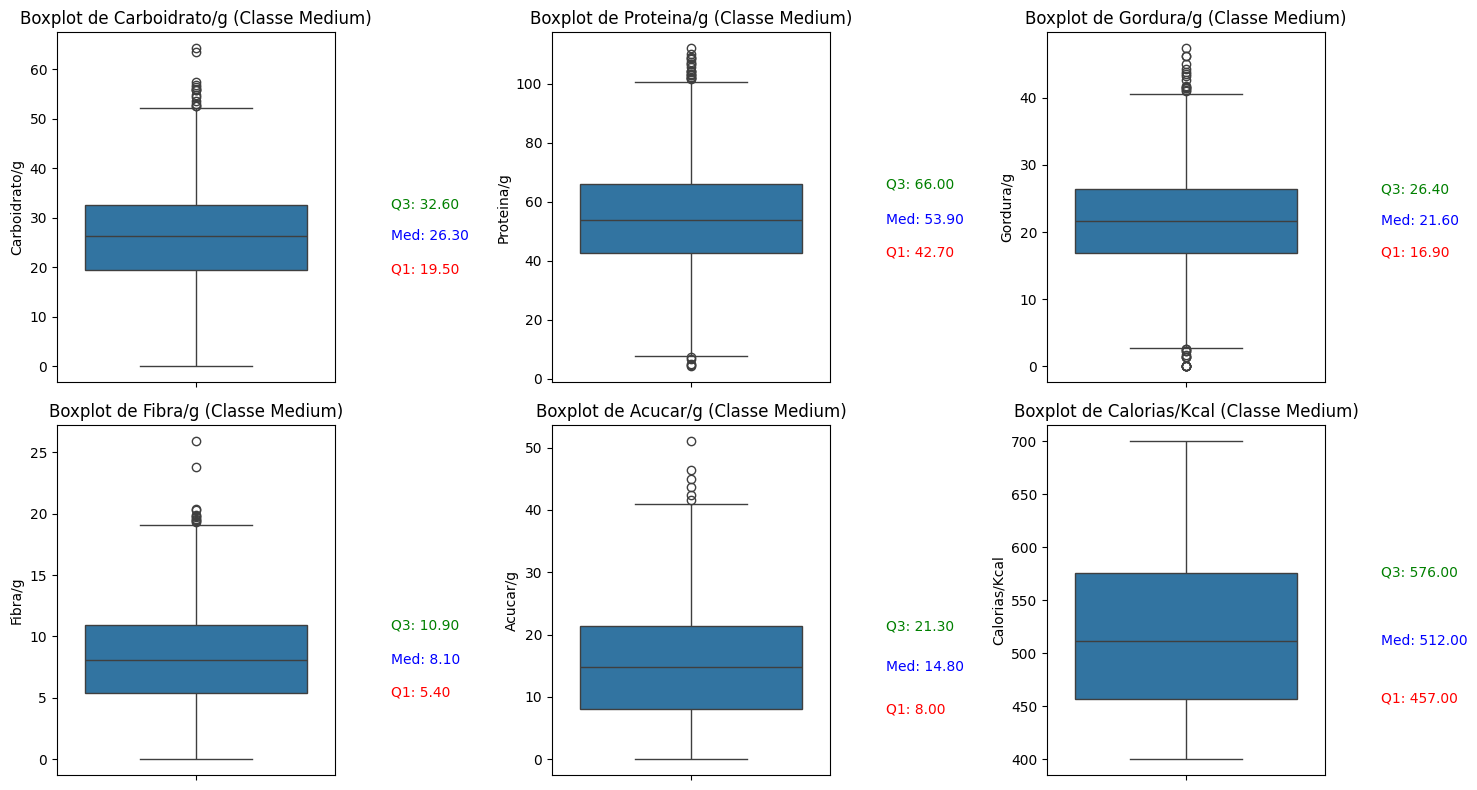


Estatísticas descritivas para a Classe de Calorias 'Medium':


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal
count,3589.000000,3589.000000,3589.000000,3589.000000,3589.000000,3589.000000
mean,26.175508,54.486041,21.698077,8.181471,14.958261,520.430203
std,9.670193,17.106196,7.129605,3.977366,9.172103,75.519102
min,0.000000,4.300000,0.000000,0.000000,0.000000,400.000000
25%,19.500000,42.700000,16.900000,5.400000,8.000000,457.000000
50%,26.300000,53.900000,21.600000,8.100000,14.800000,512.000000
75%,32.600000,66.000000,26.400000,10.900000,21.300000,576.000000
max,64.300000,112.000000,47.400000,25.900000,51.000000,700.000000


In [38]:
df_medium_calories = dafr_Calorias[dafr_Calorias['Classe_de_Calorias'] == 'medium']

# Criar boxplots para todas as características numéricas na classe 'low'
plt.figure(figsize=(15, 8))
num_cols = df_medium_calories.select_dtypes(include=np.number).columns

for i, column in enumerate(num_cols):
    # Ajustar o layout com base no número de colunas numéricas
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_medium_calories[column])
    plt.title(f'Boxplot de {column} (Classe Medium)')
    plt.ylabel(column)

    # Calcula Q1, Mediana e Q3.
    Q1 = df_medium_calories[column].quantile(0.25)
    Median = df_medium_calories[column].median()
    Q3 = df_medium_calories[column].quantile(0.75)

    # Texto Q1, Mediana e Q3 no gráfico.
    plt.text(0.7, Q1, f'Q1: {Q1:.2f}', verticalalignment='center', color='red', fontsize=10)
    plt.text(0.7, Median, f'Med: {Median:.2f}', verticalalignment='center', color='blue', fontsize=10)
    plt.text(0.7, Q3, f'Q3: {Q3:.2f}', verticalalignment='center', color='green', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEstatísticas descritivas para a Classe de Calorias 'Medium':")
display(df_medium_calories.describe())

### Classe de Calorias 'High' para todos atributos numéricos - Desbalanceado

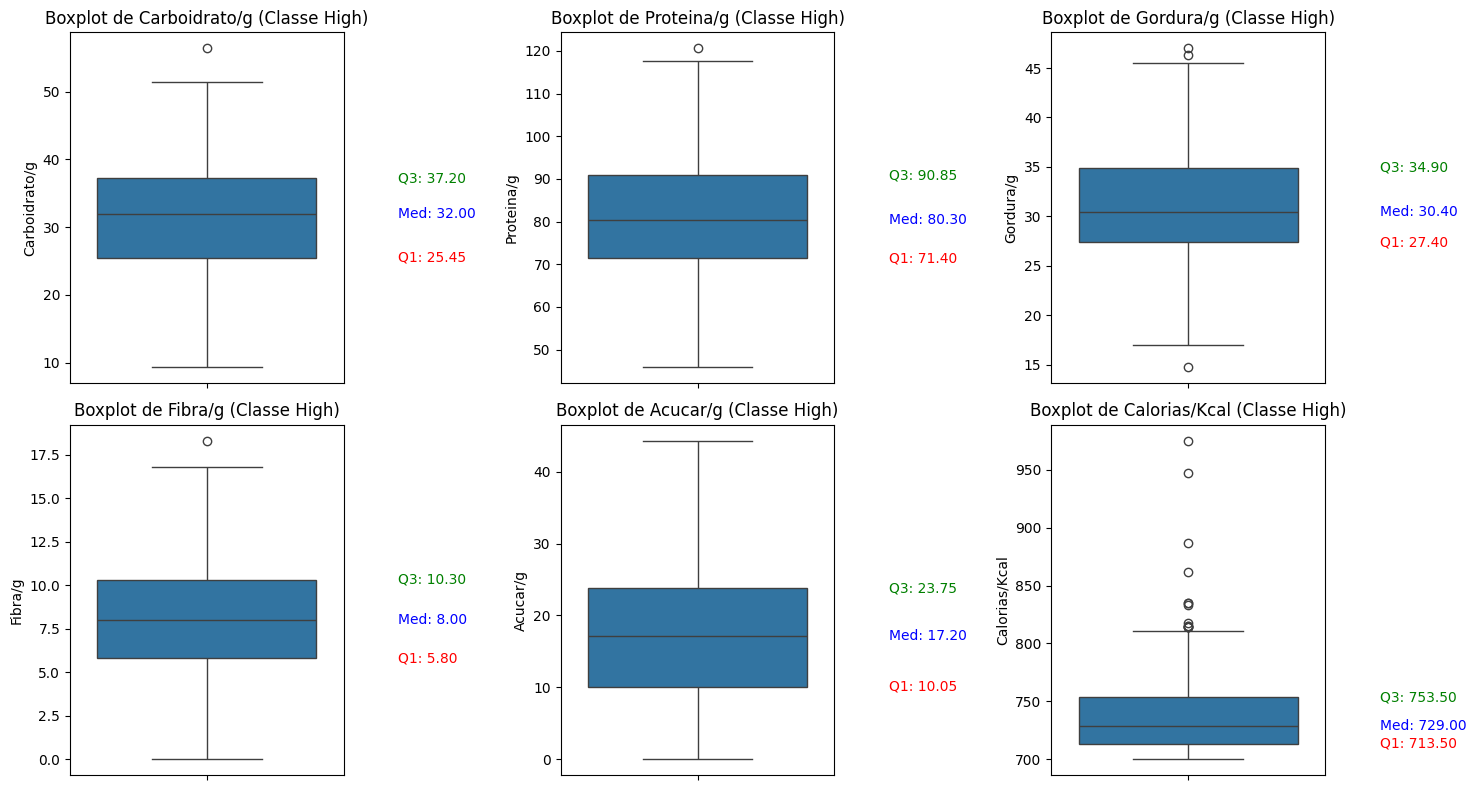


Estatísticas descritivas para a Classe de Calorias 'Low':


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal
count,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000
mean,31.935583,80.871166,30.901227,8.156442,17.400000,742.638037
std,8.595546,14.731451,5.779818,3.600001,10.070891,43.325757
min,9.400000,46.000000,14.800000,0.000000,0.000000,700.000000
25%,25.450000,71.400000,27.400000,5.800000,10.050000,713.500000
50%,32.000000,80.300000,30.400000,8.000000,17.200000,729.000000
75%,37.200000,90.850000,34.900000,10.300000,23.750000,753.500000
max,56.400000,120.600000,47.000000,18.300000,44.300000,975.000000


In [45]:
df_high_calories = dafr_Calorias[dafr_Calorias['Classe_de_Calorias'] == 'high']

# Criar boxplots para todas as características numéricas na classe 'low'
plt.figure(figsize=(15, 8))
num_cols = df_high_calories.select_dtypes(include=np.number).columns

for i, column in enumerate(num_cols):
    # Ajustar o layout com base no número de colunas numéricas
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_high_calories[column])
    plt.title(f'Boxplot de {column} (Classe High)')
    plt.ylabel(column)

    # Calcula Q1, Mediana e Q3.
    Q1 = df_high_calories[column].quantile(0.25)
    Median = df_high_calories[column].median()
    Q3 = df_high_calories[column].quantile(0.75)

    # Texto Q1, Mediana e Q3 no gráfico.
    plt.text(0.7, Q1, f'Q1: {Q1:.2f}', verticalalignment='center', color='red', fontsize=10)
    plt.text(0.7, Median, f'Med: {Median:.2f}', verticalalignment='center', color='blue', fontsize=10)
    plt.text(0.7, Q3, f'Q3: {Q3:.2f}', verticalalignment='center', color='green', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEstatísticas descritivas para a Classe de Calorias 'Low':")
display(df_high_calories.describe())

### Classe de Calorias 'Low' para todos atributos numéricos - Balanceado

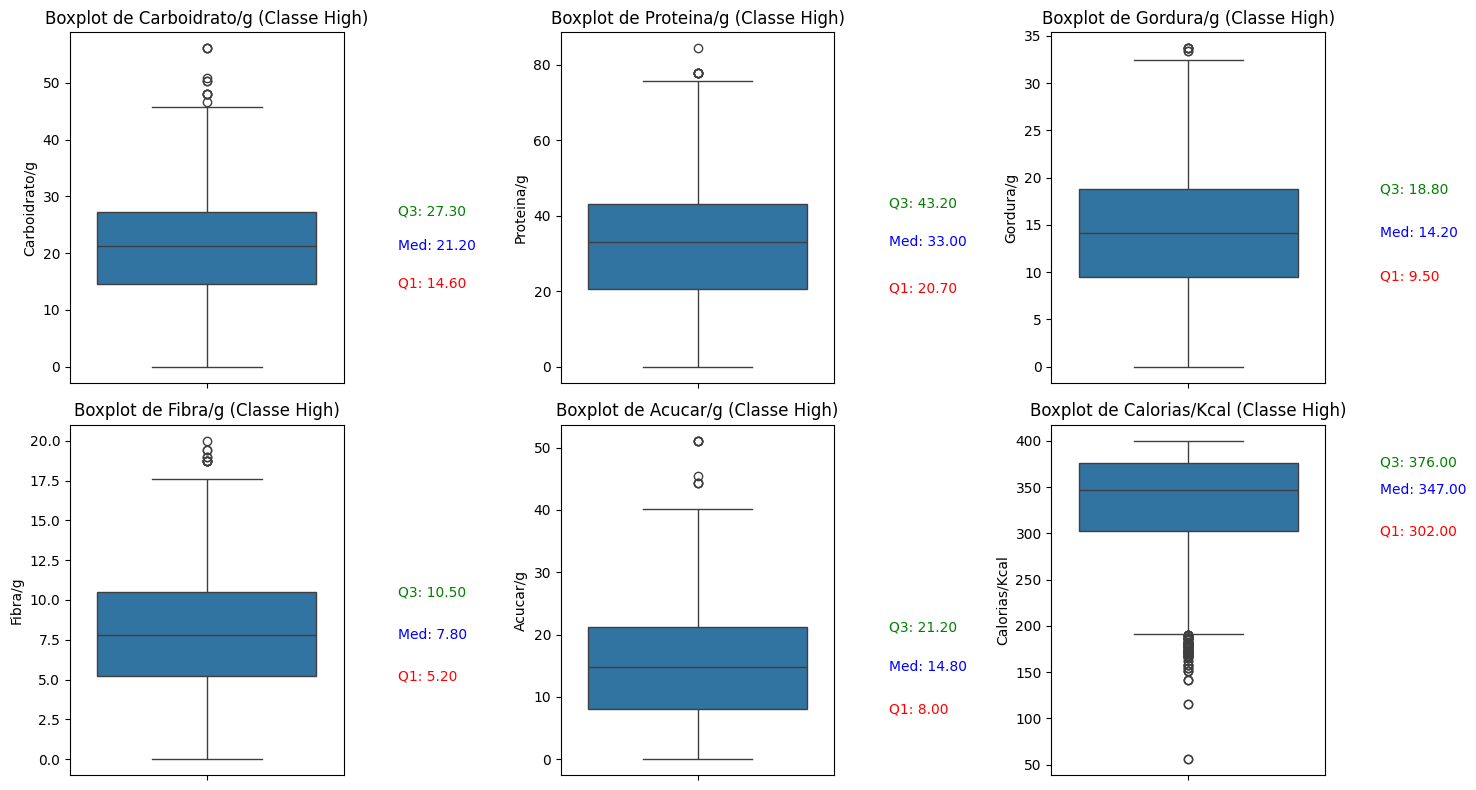


Estatísticas descritivas para a Classe de Calorias 'Low':


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal
count,3589.000000,3589.000000,3589.000000,3589.000000,3589.000000,3589.000000
mean,21.035581,32.332767,14.080942,7.817804,15.239342,330.501811
std,9.346773,15.915792,6.639662,3.767439,9.517200,57.195589
min,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000
25%,14.600000,20.700000,9.500000,5.200000,8.000000,302.000000
50%,21.200000,33.000000,14.200000,7.800000,14.800000,347.000000
75%,27.300000,43.200000,18.800000,10.500000,21.200000,376.000000
max,56.100000,84.400000,33.700000,20.000000,51.100000,400.000000


In [44]:
df_low_calories_balanced = dafr_Calorias_balanced[dafr_Calorias_balanced['Classe_de_Calorias'] == 'low']

# Criar boxplots para todas as características numéricas na classe 'low'
plt.figure(figsize=(15, 8))
num_cols = df_low_calories_balanced.select_dtypes(include=np.number).columns

for i, column in enumerate(num_cols):
    # Ajustar o layout com base no número de colunas numéricas
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_low_calories_balanced[column])
    plt.title(f'Boxplot de {column} (Classe High)')
    plt.ylabel(column)

    # Calcula Q1, Mediana e Q3.
    Q1 = df_low_calories_balanced[column].quantile(0.25)
    Median = df_low_calories_balanced[column].median()
    Q3 = df_low_calories_balanced[column].quantile(0.75)

    # Texto Q1, Mediana e Q3 no gráfico.
    plt.text(0.7, Q1, f'Q1: {Q1:.2f}', verticalalignment='center', color='red', fontsize=10)
    plt.text(0.7, Median, f'Med: {Median:.2f}', verticalalignment='center', color='blue', fontsize=10)
    plt.text(0.7, Q3, f'Q3: {Q3:.2f}', verticalalignment='center', color='green', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEstatísticas descritivas para a Classe de Calorias 'Low':")
display(df_low_calories_balanced.describe())

### Classe de Calorias 'Medium' para todos atributos numéricos - Balanceado

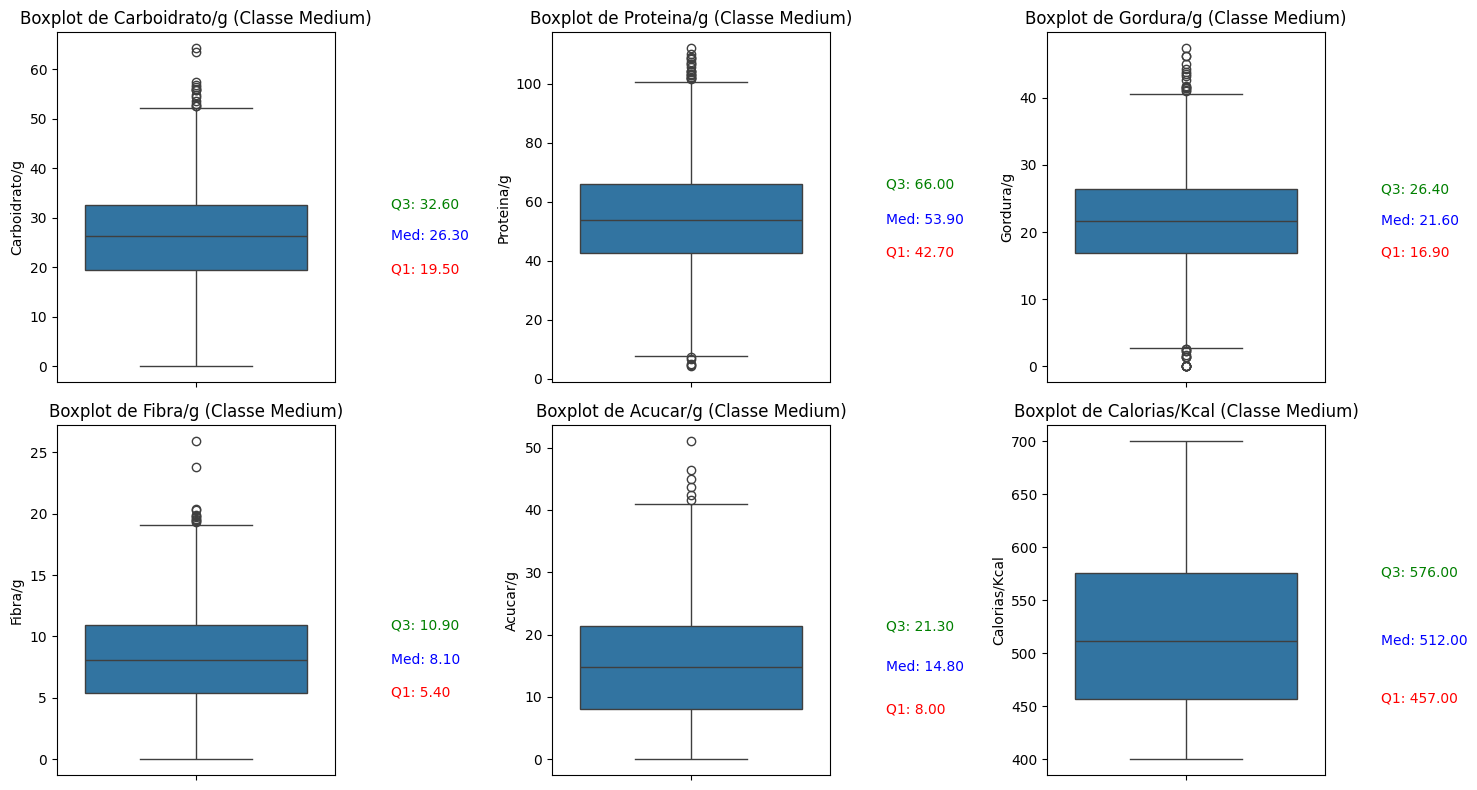


Estatísticas descritivas para a Classe de Calorias 'Medium' (Balanceado):


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal
count,3589.000000,3589.000000,3589.000000,3589.000000,3589.000000,3589.000000
mean,26.175508,54.486041,21.698077,8.181471,14.958261,520.430203
std,9.670193,17.106196,7.129605,3.977366,9.172103,75.519102
min,0.000000,4.300000,0.000000,0.000000,0.000000,400.000000
25%,19.500000,42.700000,16.900000,5.400000,8.000000,457.000000
50%,26.300000,53.900000,21.600000,8.100000,14.800000,512.000000
75%,32.600000,66.000000,26.400000,10.900000,21.300000,576.000000
max,64.300000,112.000000,47.400000,25.900000,51.000000,700.000000


In [52]:
# Create boxplots for all numerical characteristics in the 'Medium' calorie class (using balanced data)
df_medium_calories_balanced = dafr_Calorias_balanced[dafr_Calorias_balanced['Classe_de_Calorias'] == 'medium']

plt.figure(figsize=(15, 8))
num_cols = df_medium_calories_balanced.select_dtypes(include=np.number).columns

for i, column in enumerate(num_cols):
    # Adjust layout based on the number of numerical columns
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_medium_calories_balanced[column])
    plt.title(f'Boxplot de {column} (Classe Medium)')
    plt.ylabel(column)

    # Calculate Q1, Median, and Q3.
    Q1 = df_medium_calories_balanced[column].quantile(0.25)
    Median = df_medium_calories_balanced[column].median()
    Q3 = df_medium_calories_balanced[column].quantile(0.75)

    # Annotate Q1, Median, and Q3 on the plot.
    plt.text(0.7, Q1, f'Q1: {Q1:.2f}', verticalalignment='center', color='red', fontsize=10)
    plt.text(0.7, Median, f'Med: {Median:.2f}', verticalalignment='center', color='blue', fontsize=10)
    plt.text(0.7, Q3, f'Q3: {Q3:.2f}', verticalalignment='center', color='green', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEstatísticas descritivas para a Classe de Calorias 'Medium' (Balanceado):")
display(df_medium_calories_balanced.describe())

### Classe de Calorias 'High' para todos atributos numéricos - Balanceado

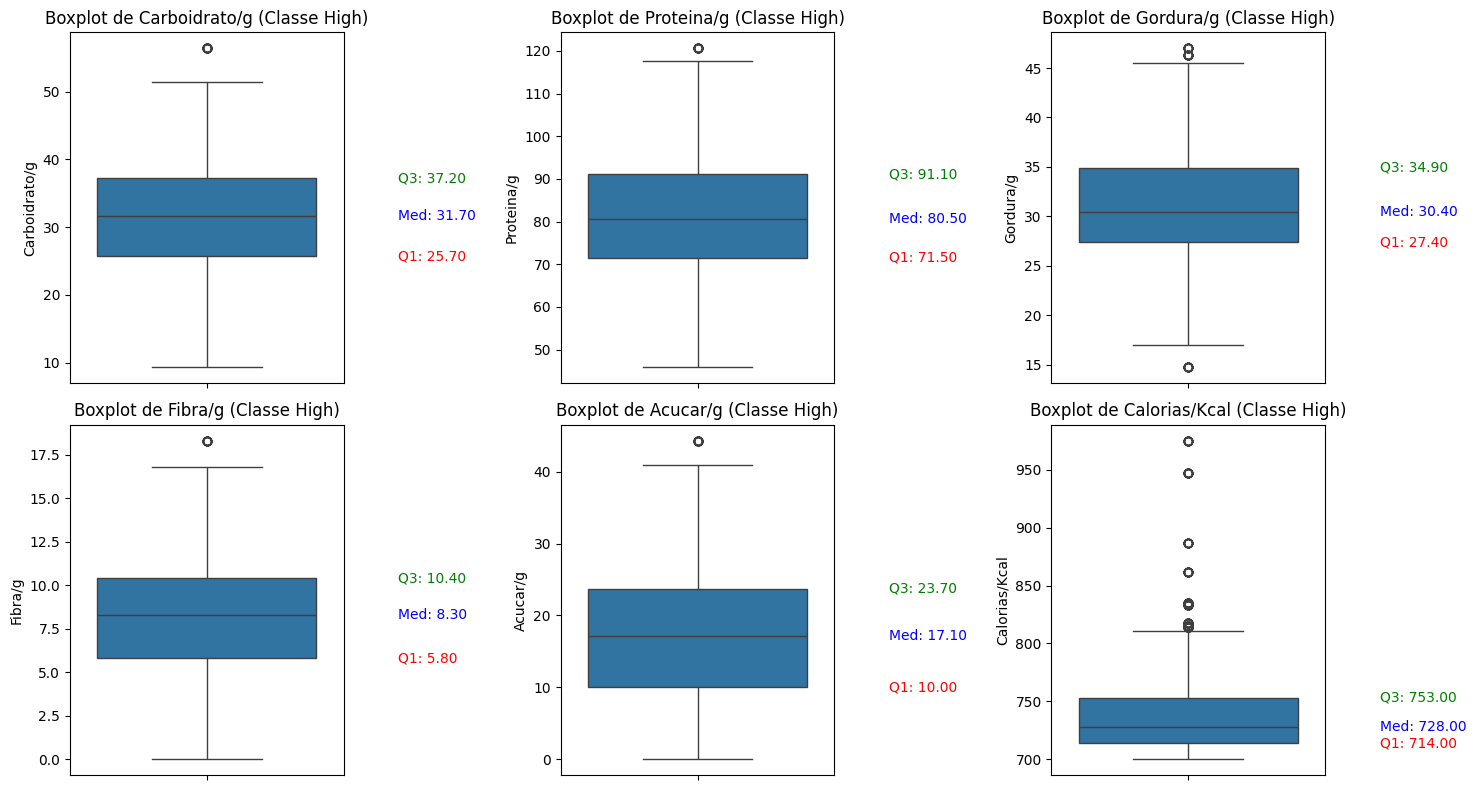


Estatísticas descritivas para a Classe de Calorias 'High' (Balanceado):


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal
count,3589.000000,3589.000000,3589.000000,3589.000000,3589.000000,3589.000000
mean,31.926219,81.310226,30.835219,8.261661,17.279019,742.511284
std,8.428001,14.684338,5.640817,3.632437,9.995123,42.808604
min,9.400000,46.000000,14.800000,0.000000,0.000000,700.000000
25%,25.700000,71.500000,27.400000,5.800000,10.000000,714.000000
50%,31.700000,80.500000,30.400000,8.300000,17.100000,728.000000
75%,37.200000,91.100000,34.900000,10.400000,23.700000,753.000000
max,56.400000,120.600000,47.000000,18.300000,44.300000,975.000000


In [53]:
# Create boxplots for all numerical characteristics in the 'High' calorie class (using balanced data)
df_high_calories_balanced = dafr_Calorias_balanced[dafr_Calorias_balanced['Classe_de_Calorias'] == 'high']

plt.figure(figsize=(15, 8))
num_cols = df_high_calories_balanced.select_dtypes(include=np.number).columns

for i, column in enumerate(num_cols):
    # Adjust layout based on the number of numerical columns
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df_high_calories_balanced[column])
    plt.title(f'Boxplot de {column} (Classe High)')
    plt.ylabel(column)

    # Calculate Q1, Median, and Q3.
    Q1 = df_high_calories_balanced[column].quantile(0.25)
    Median = df_high_calories_balanced[column].median()
    Q3 = df_high_calories_balanced[column].quantile(0.75)

    # Annotate Q1, Median, and Q3 on the plot.
    plt.text(0.7, Q1, f'Q1: {Q1:.2f}', verticalalignment='center', color='red', fontsize=10)
    plt.text(0.7, Median, f'Med: {Median:.2f}', verticalalignment='center', color='blue', fontsize=10)
    plt.text(0.7, Q3, f'Q3: {Q3:.2f}', verticalalignment='center', color='green', fontsize=10)

plt.tight_layout()
plt.show()

print("\nEstatísticas descritivas para a Classe de Calorias 'High' (Balanceado):")
display(df_high_calories_balanced.describe())

O boxplot do comprimento da pétala por espécie demonstra claramente que a Iris setosa tem pétalas significativamente mais curtas do que as outras duas espécies. Há uma sobreposição entre Iris versicolor e Iris virginica, mas as medianas e as caixas indicam uma distinção.

Quais impressões o boxplot trouxe?

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

Informaçõe da Matriz de Correlação do Dataframe Calorias - Desbalanceadas.

In [54]:
# Matriz de correlação
print("\nMatriz de Correlação:")
# Seleciona apenas as colunas numéricas para o cálculo da correlação
numeric_df = dafr_Calorias.select_dtypes(include=np.number)
print(numeric_df.corr())


Matriz de Correlação:
               Carboidrato/g  Proteina/g  Gordura/g   Fibra/g  Acucar/g  \
Carboidrato/g       1.000000   -0.002738  -0.001996  0.002640  0.016107   
Proteina/g         -0.002738    1.000000  -0.006142 -0.014636 -0.005125   
Gordura/g          -0.001996   -0.006142   1.000000  0.012373  0.020137   
Fibra/g             0.002640   -0.014636   0.012373  1.000000 -0.035328   
Acucar/g            0.016107   -0.005125   0.020137 -0.035328  1.000000   
Calorias/Kcal       0.328377    0.683536   0.594464  0.007370  0.011394   

               Calorias/Kcal  
Carboidrato/g       0.328377  
Proteina/g          0.683536  
Gordura/g           0.594464  
Fibra/g             0.007370  
Acucar/g            0.011394  
Calorias/Kcal       1.000000  


Grafico da Matriz de Correlação do Dataframe Calorias - Desbalanceadas.

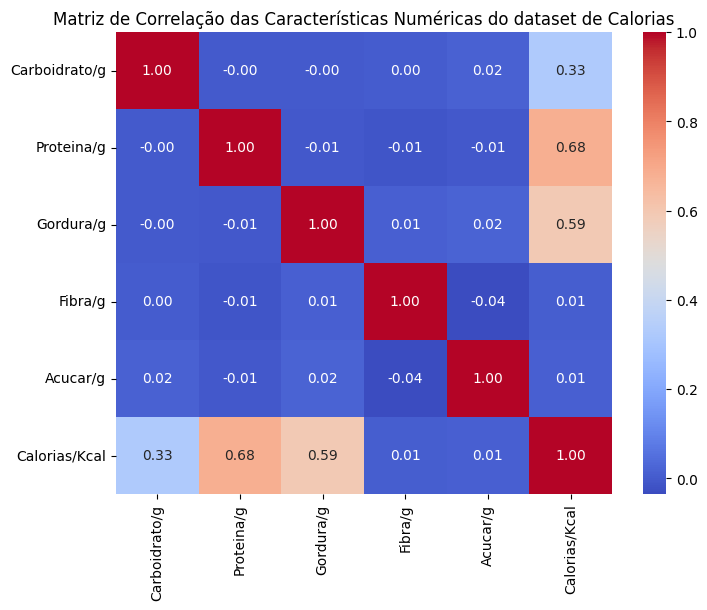

In [55]:
#cria uma nova figura para o gráfico com um tamanho de 8 polegadas de largura por 6 polegadas de altura.
#Isso ajuda a controlar as dimensões do gráfico para melhor visualização.
plt.figure(figsize=(8, 6))
#Cria o histograma.
# mapa de calor das variáveis numéricas
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do dataset de Calorias')
plt.show()

Informaçõe da Matriz de Correlação do Dataframe Calorias - Balanceadalanceadas.

In [56]:
# Matriz de correlação
print("\nMatriz de Correlação:")
# Seleciona apenas as colunas numéricas para o cálculo da correlação
numeric_df_balanced = dafr_Calorias_balanced.select_dtypes(include=np.number)
print(numeric_df.corr())


Matriz de Correlação:
               Carboidrato/g  Proteina/g  Gordura/g   Fibra/g  Acucar/g  \
Carboidrato/g       1.000000   -0.002738  -0.001996  0.002640  0.016107   
Proteina/g         -0.002738    1.000000  -0.006142 -0.014636 -0.005125   
Gordura/g          -0.001996   -0.006142   1.000000  0.012373  0.020137   
Fibra/g             0.002640   -0.014636   0.012373  1.000000 -0.035328   
Acucar/g            0.016107   -0.005125   0.020137 -0.035328  1.000000   
Calorias/Kcal       0.328377    0.683536   0.594464  0.007370  0.011394   

               Calorias/Kcal  
Carboidrato/g       0.328377  
Proteina/g          0.683536  
Gordura/g           0.594464  
Fibra/g             0.007370  
Acucar/g            0.011394  
Calorias/Kcal       1.000000  


Grafico da Matriz de Correlação do Dataframe Calorias - Balanceadas.

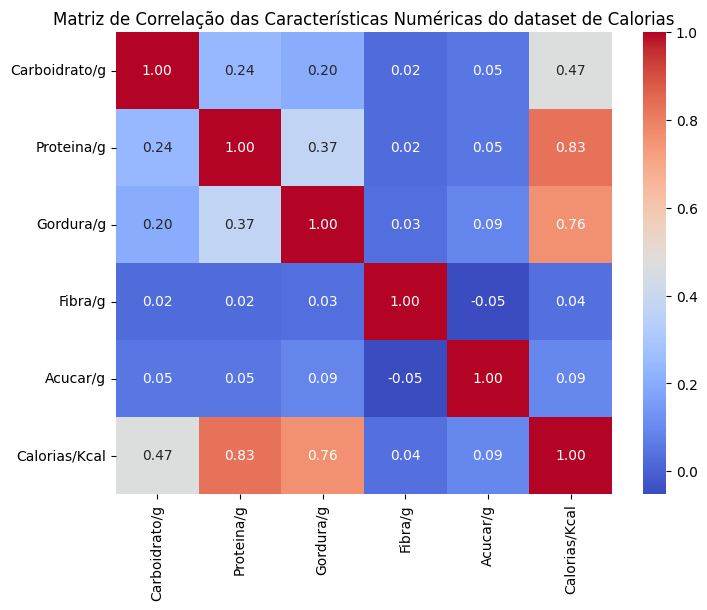

In [57]:
#cria uma nova figura para o gráfico com um tamanho de 8 polegadas de largura por 6 polegadas de altura.
#Isso ajuda a controlar as dimensões do gráfico para melhor visualização.
plt.figure(figsize=(8, 6))
#Cria o histograma.
# mapa de calor das variáveis numéricas
sns.heatmap(numeric_df_balanced.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do dataset de Calorias')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

Dataframe Calorias Desbalanceado.

In [58]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
dafr_Calorias.isnull().sum()

Valores nulos no dataset Iris:


,0
Carboidrato/g,0
Proteina/g,0
Gordura/g,0
Fibra/g,0
Acucar/g,0
Calorias/Kcal,0
Classe_de_Calorias,0


Dataframe Calorias Balanceado.

In [59]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
dafr_Calorias_balanced.isnull().sum()

Valores nulos no dataset Iris:


,0
Carboidrato/g,0
Proteina/g,0
Gordura/g,0
Fibra/g,0
Acucar/g,0
Calorias/Kcal,0
Classe_de_Calorias,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

Separar as características de medição do atributo 'Classe_de_Calorias' é categórico. - Desbalanceado.

In [129]:
# Separar features (X) e target (y)
X = dafr_Calorias.drop('Classe_de_Calorias', axis=1)
y = dafr_Calorias['Classe_de_Calorias']

Dividir os dados em conjuntos de treino e teste - Desbalanceado.

In [155]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Dividir os dados em conjuntos de treino e teste e balancear as informações

In [157]:
# Dividir os dados em conjuntos de treino e teste e balancear as informações
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (7536, 6)
Dimensões de X_test: (3231, 6)
Dimensões de y_train: (7536,)
Dimensões de y_test: (3231,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [135]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [136]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [116]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [117]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   Carboidrato/g  Proteina/g  Gordura/g   Fibra/g  Acucar/g  Calorias/Kcal
0       0.251969    0.575456   0.563830  0.478764  0.442270       0.519042
1       0.233071    0.483416   0.397872  0.166023  0.000000       0.375408
2       0.294488    0.309287   0.312766  0.158301  0.352250       0.299238
3       0.483465    0.532338   0.831915  0.162162  0.397260       0.755169
4       0.474016    0.465174   0.574468  0.343629  0.309198       0.557127


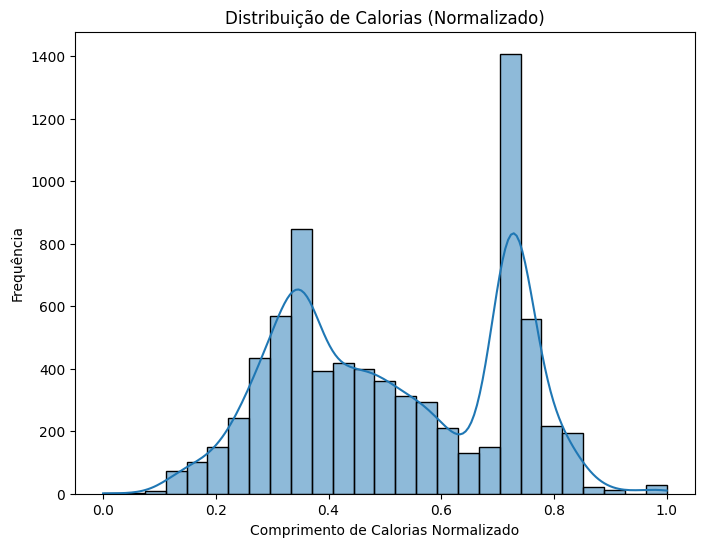

In [118]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Calorias/Kcal'], kde=True)
plt.title('Distribuição de Calorias (Normalizado)')
plt.xlabel('Comprimento de Calorias Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [158]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [159]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [160]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [161]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
   Carboidrato/g  Proteina/g  Gordura/g   Fibra/g  Acucar/g  Calorias/Kcal
0      -1.008507    0.516289   0.459638  1.123037  0.712808       0.013360
1      -1.125700    0.083075  -0.364596 -0.995675 -1.636931      -0.724424
2      -0.744823   -0.736521  -0.787279 -1.047988  0.234543      -1.115673
3       0.427105    0.313342   1.791091 -1.021832  0.473675       1.226232
4       0.368508   -0.002788   0.512473  0.207544  0.005807       0.208984


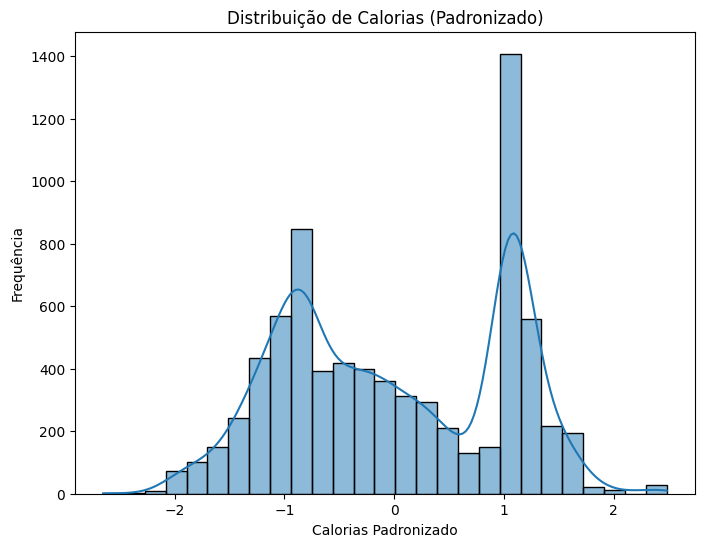

In [162]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Calorias/Kcal'], kde=True)
plt.title('Distribuição de Calorias (Padronizado)')
plt.xlabel('Calorias Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Novas características (feature engineering)

Observei que o valor da coluna **Calorias/Kcal** não está batendo com a regra de cálculo de Kcal e vou investigar.

Calcular os Macronutrientes em Kcal.

Apliquei o valor de Kcal por gramas ingeridas dos macronutrientes, conforme regras abaixo, e calculei as 5 primeiras atributos (**Carboidrato/g; Proteina/g; Gordura/g; Fibra/g e Acucar/g**) e depois somei todos os resultados na variável **soma_primeiras_5**.


*Regras para formar o valor dos dados do atributo* ***Calorias:***

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal


In [197]:
# Seleciona as 5 primeiras colunas (macronutrientes)
macronutrientes = dafr_Calorias_balanced.iloc[:, :5]

# Define os coeficientes de caloria por grama para cada macronutriente
coeficientes_calorias = np.array([4, 4, 9, 2, 4])


# Multiplica os macronutrientes pelos seus respectivos coeficientes
calorias_por_macronutriente = macronutrientes.mul(coeficientes_calorias, axis=1);


# Exibe as 10 primeiras linhas dos valores das 5 primeiras colunas
print("Valores das 5 primeiras colunas em gramas (10 primeiras linhas):\n")
print(macronutrientes.head(10))
print("-----------------------------------------------------------------")


# Mostra o resultado das 10 primeiras linhas das 5 primeiras Colunas
print("Transformar em Kcal (10 primeiras linhas):")
print("Cálculos (Carboidrato/g x 4 - Proteina/g x 4 - Gordura/g x 9:")
print("Fibra/g x 2 - Acucar/g x 4):\n")
print(calorias_por_macronutriente.head(10))
print("-----------------------------------------------------------------")


Valores das 5 primeiras colunas em gramas (10 primeiras linhas):

   Carboidrato/g  Proteina/g  Gordura/g  Fibra/g  Acucar/g
0           22.5        65.2       13.7      9.9      26.7
1           15.9        20.7       16.8      7.6      15.0
2           28.3        62.4       14.5     10.8      15.3
3           23.3        18.6        7.9     17.0       0.2
4           30.8        55.1       31.9     12.5       7.2
5           35.5        72.8       19.6      6.7      11.9
6           16.1        45.1        9.8     12.5      21.0
7           38.1        23.1       17.1      0.0       5.6
8           31.6        43.3       17.4      5.3      17.4
9           21.4        76.1       18.1      2.0      23.0
-----------------------------------------------------------------
Transformar em Kcal (10 primeiras linhas):
Cálculos (Carboidrato/g x 4 - Proteina/g x 4 - Gordura/g x 9:
Fibra/g x 2 - Acucar/g x 4):

   Carboidrato/g  Proteina/g  Gordura/g  Fibra/g  Acucar/g
0           90.0       26

Somei os resultados dos Macronutrientes calculados em Kcal e comparar com o campo Calorias/Kcal da tabela original.

In [198]:
# Soma os valores das colunas por linha
soma_primeiras_5 = calorias_por_macronutriente.sum(axis=1)

# Mostra o resultado das 10 primeiras linhas
print("Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):")
print(soma_primeiras_5.head(10))
print("-----------------------------------------------------------------")

# Exibe as 10 primeiras linhas do valor 'Calorias/Kcal'
print("\nValores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):")
print(dafr_Calorias['Calorias/Kcal'].head(10))

Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
dtype: float64
-----------------------------------------------------------------

Valores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):
0    479.0
1    316.0
2    524.0
3    250.0
4    602.0
5    634.0
6    374.0
7    379.0
8    418.0
9    566.0
Name: Calorias/Kcal, dtype: float64


Gráfico de linhas com a comparação entre o campo original 'Calorias/Kcal' com o valor da Variável soma_primeiras_5

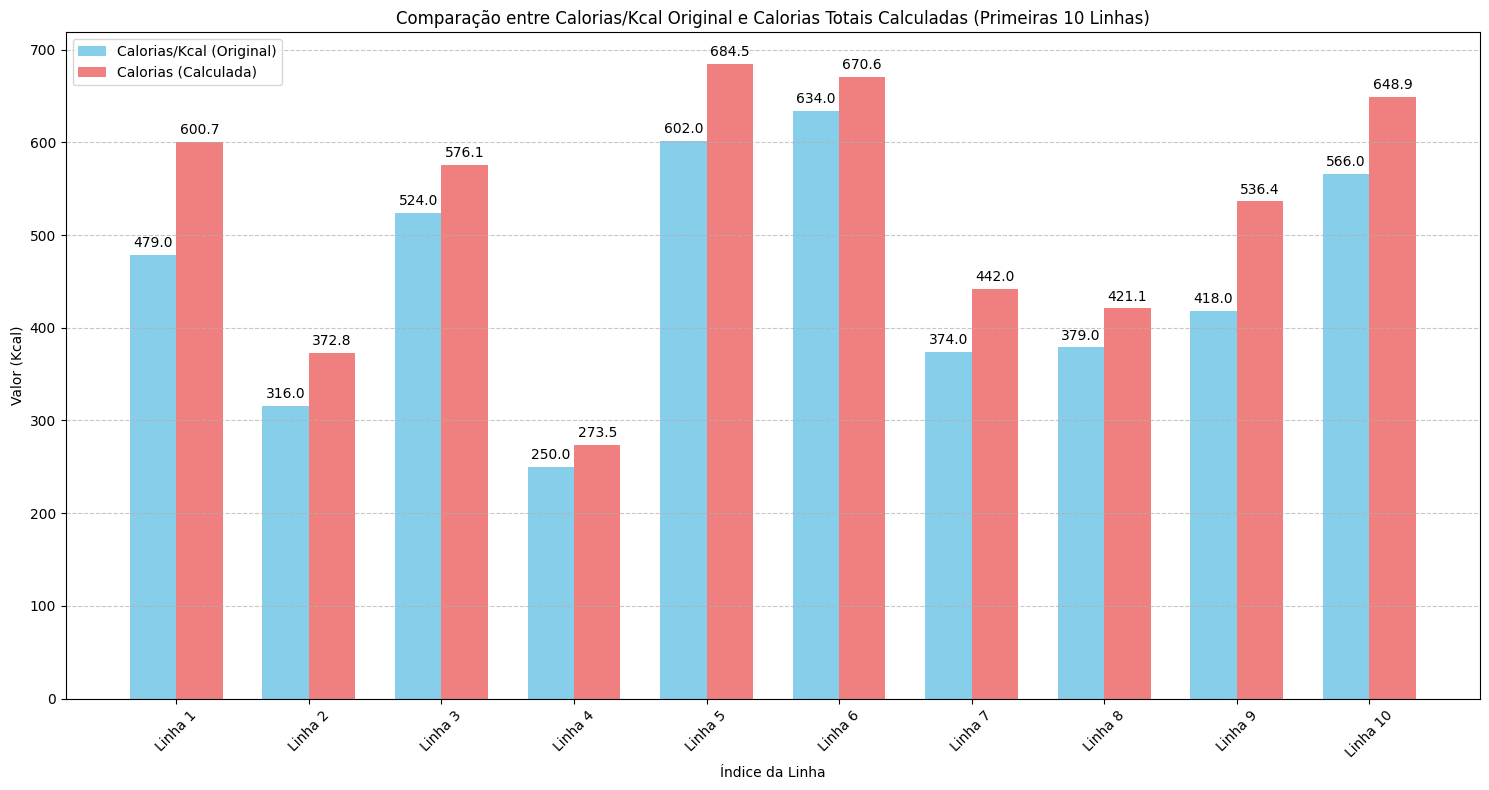

In [199]:
# obtendo as 10 primeiras linhas e comparando
calorias_original_10 = dafr_Calorias_balanced['Calorias/Kcal'].head(10)
calorias_calculada_10 = soma_primeiras_5.head(10)

# criando um index para as barras
indices = np.arange(len(calorias_original_10))
bar_width = 0.35

plt.figure(figsize=(15, 8))

# Plot original 'Calorias/Kcal'
bars1 = plt.bar(indices - bar_width/2, calorias_original_10, bar_width, label='Calorias/Kcal (Original)', color='skyblue')

# Plot calculado 'soma_primeiras_5'
bars2 = plt.bar(indices + bar_width/2, calorias_calculada_10, bar_width, label='Calorias (Calculada)', color='lightcoral')

# adicionando os valores no topo da barra
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

plt.xlabel('Índice da Linha')
plt.ylabel('Valor (Kcal)')
plt.title('Comparação entre Calorias/Kcal Original e Calorias Totais Calculadas (Primeiras 10 Linhas)')
plt.xticks(indices, [f'Linha {i}' for i in range(1, 11)], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Como suspeitei os valores do campo **Calorias/Kcal (Original)** estavam incorretos de acordo com a regra de **Calorias (Calculada).**

No gráfico de barras acima, percebi que no resultado da variável **Calorias (Calculada)** que é a soma de todos macronutrientes, em Kcal, está diferente do cálculo do atributo - ***Calorias/Kcal***

###Solução para resolver o problema de Cálculo errado:
Criar um novo atributo e recalcular os valores de acordo com a regra de **Calorias (Kcal)** de recalcular os valores.

Além de criar e popular novos atributos para realizar a análise.


Incluí os seguintes campos, com dados sintéticos, no dataset original (Calorie Dataset) para poder testar minhas Hipótestes:
- ***UF:*** Em siglas
- ***Idade:*** Idade de 18 a 81 anos
- ***Sexo:*** ***F*** - Feminio, ***M*** - Masculino, ***O*** - Outros
- ***Refeição:*** Café da manhã, Almoço, Jantar, Lanche
- ***Calorias Totais:*** É o resultado do seguinte cálculo:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal
- ***Nível de Calorias:*** (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)


Criando os atributos e populando com dados aleatórios no início do DataSet:


*   **UF:** Em siglas
*   **Idade:** Idade de 18 a 81 anos
*   **Sexo:**  ***F*** - Feminino, ***M*** - Masculino, ***O*** - Outros
*   **Refeição:** Café da manhã, Almoço, Lanche, Jantar,

**OBS:** *Os atributos e dados originais serão mantidos.*

In [200]:
# Listas de valores para as novas colunas
uflist = ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO']
sexo_list = ['F', 'M', 'O']
refeicao_list = ['CAFE DA MANHA', 'ALMOCO', 'JANTAR', 'LANCHE']

# Garante que dafr_Calorias_Nova é um DataFrame independente e não uma view
dafr_Calorias_Nova = dafr_Calorias_balanced.copy()

# Gera dados aleatórios para as novas colunas
new_uf = np.random.choice(uflist, size=len(dafr_Calorias_Nova))
new_idade = np.random.randint(18, 81, size=len(dafr_Calorias_Nova)) # Idade entre 18 e 80
new_sexo = np.random.choice(sexo_list, size=len(dafr_Calorias_Nova))
new_refeicao = np.random.choice(refeicao_list, size=len(dafr_Calorias_Nova))

# Cria um DataFrame temporário com as novas colunas
new_cols_df = pd.DataFrame({
    'UF': new_uf,
    'Idade': new_idade,
    'Sexo': new_sexo,
    'Refeicao': new_refeicao
})

# Concatena as novas colunas no início do DataFrame existente
dafr_Calorias_Nova = pd.concat([new_cols_df, dafr_Calorias_Nova], axis=1)

print("DataFrame 'dafr_Calorias_Nova' atualizado com as novas colunas no início:")
display(dafr_Calorias_Nova.head())

DataFrame 'dafr_Calorias_Nova' atualizado com as novas colunas no início:


,UF,Idade,Sexo,Refeicao,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias
0,SC,27,M,ALMOCO,22.5,65.2,13.7,9.9,26.7,479.0,medium
1,CE,70,M,JANTAR,15.9,20.7,16.8,7.6,15.0,316.0,low
2,MG,48,F,LANCHE,28.3,62.4,14.5,10.8,15.3,524.0,medium
3,RR,67,F,CAFE DA MANHA,23.3,18.6,7.9,17.0,0.2,250.0,low
4,DF,60,M,JANTAR,30.8,55.1,31.9,12.5,7.2,602.0,medium


Criando os atributos e populando com dados aleatórios no fim do DataSet:


- ***Calorias Totais:*** com os seguintes cálculos:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal
- ***Nível de Calorias:*** com as seguintes regras: (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)


**OBS:** *Os atributos e dados originais serão mantidos.*

In [201]:
# Calcular 'Calorias_Totais'
dafr_Calorias_Nova['Calorias_Totais/Kcal'] = (
    dafr_Calorias_Nova['Carboidrato/g'] * 4 +
    dafr_Calorias_Nova['Proteina/g'] * 4 +
    dafr_Calorias_Nova['Gordura/g'] * 9 +
    dafr_Calorias_Nova['Fibra/g'] * 2 +
    dafr_Calorias_Nova['Acucar/g'] * 4
)

# Função para categorizar o nível de calorias
def categorizar_nivel_calorias(calorias):
    if calorias < 400:
        return 'BAIXA'
    elif 400 <= calorias <= 699:
        return 'MEDIA'
    else:
        return 'ALTA'

# Aplicar a função para criar a coluna 'Nível_Calorias'
dafr_Calorias_Nova['Nivel_Calorias'] = dafr_Calorias_Nova['Calorias_Totais/Kcal'].apply(categorizar_nivel_calorias)

print("DataFrame 'dafr_Calorias_Nova' atualizado com 'Calorias_Totais' e 'Nível_Calorias':")
display(dafr_Calorias_Nova.head(10))

DataFrame 'dafr_Calorias_Nova' atualizado com 'Calorias_Totais' e 'Nível_Calorias':


,UF,Idade,Sexo,Refeicao,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias,Calorias_Totais/Kcal,Nivel_Calorias
0,SC,27,M,ALMOCO,22.5,65.2,13.7,9.9,26.7,479.0,medium,600.7,MEDIA
1,CE,70,M,JANTAR,15.9,20.7,16.8,7.6,15.0,316.0,low,372.8,BAIXA
2,MG,48,F,LANCHE,28.3,62.4,14.5,10.8,15.3,524.0,medium,576.1,MEDIA
3,RR,67,F,CAFE DA MANHA,23.3,18.6,7.9,17.0,0.2,250.0,low,273.5,BAIXA
4,DF,60,M,JANTAR,30.8,55.1,31.9,12.5,7.2,602.0,medium,684.5,MEDIA
5,MA,33,F,ALMOCO,35.5,72.8,19.6,6.7,11.9,634.0,medium,670.6,MEDIA
6,CE,33,M,JANTAR,16.1,45.1,9.8,12.5,21.0,374.0,low,442.0,MEDIA
7,AP,26,F,LANCHE,38.1,23.1,17.1,0.0,5.6,379.0,low,421.1,MEDIA
8,PR,20,O,LANCHE,31.6,43.3,17.4,5.3,17.4,418.0,medium,536.4,MEDIA
9,PE,63,M,ALMOCO,21.4,76.1,18.1,2.0,23.0,566.0,medium,648.9,MEDIA


Resultado das 10 primeiras linhas e depois comparado com os valores do campo Calorias_Totais/Kcal criado.

In [202]:
# Mostra o resultado das 10 primeiras linhas
print("Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):")
print(soma_primeiras_5.head(10))
print("-----------------------------------------------------------------")

# Exibe as 10 primeiras linhas do valor 'Calorias/Kcal'
print("\nValores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):")
print(dafr_Calorias_Nova['Calorias_Totais/Kcal'].head(10))

Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
dtype: float64
-----------------------------------------------------------------

Valores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
Name: Calorias_Totais/Kcal, dtype: float64


Depois da transformção, mostro no gràfico de Barras que os dados do campo **Calorias_Totais/Kcal** e está igual aos dados cálculos com a regra de formação de calorias.

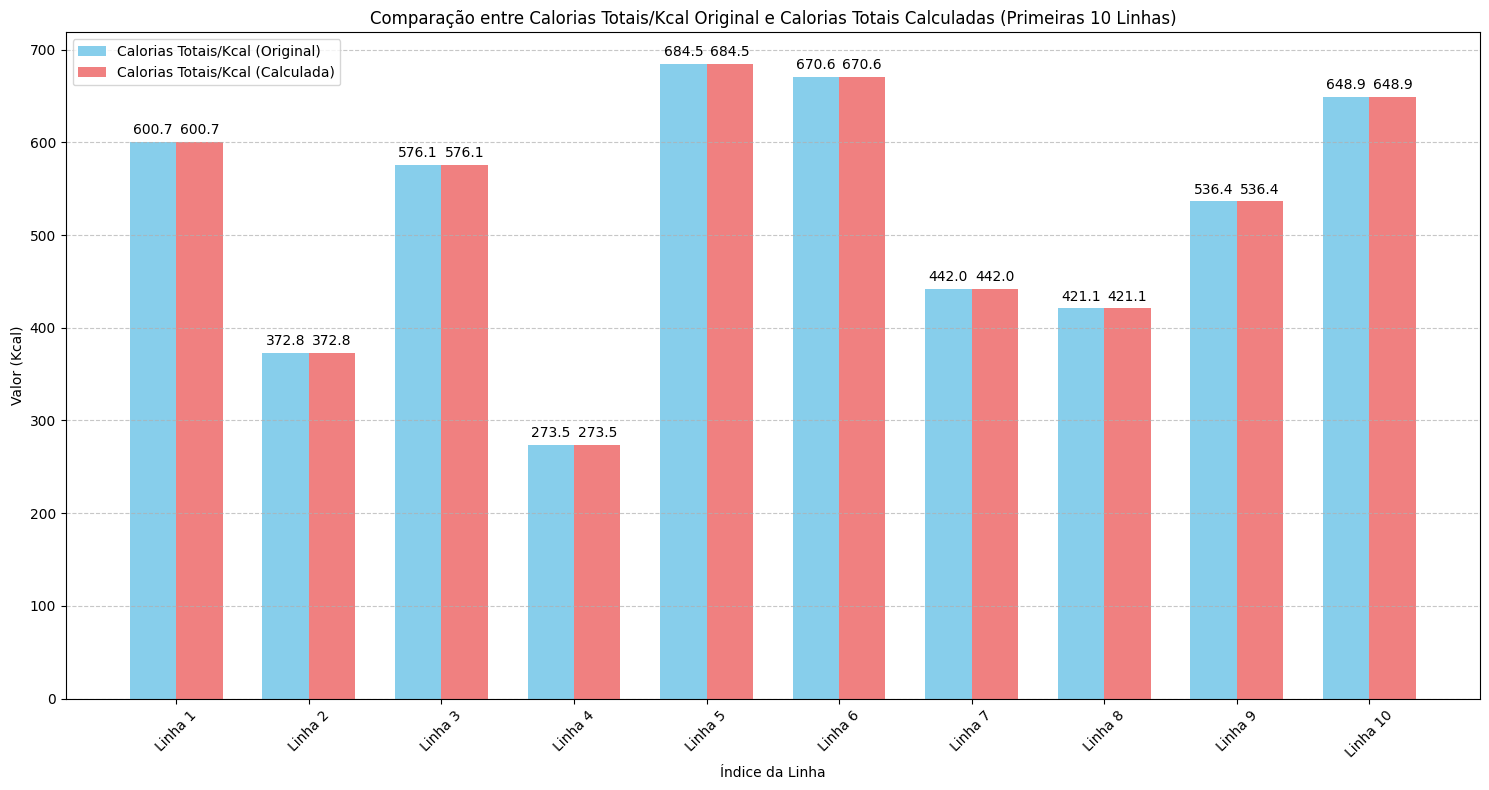

In [203]:
# obtendo as 10 primeiras linhas e comparando
calorias_original_10 = dafr_Calorias_Nova['Calorias_Totais/Kcal'].head(10)
calorias_calculada_10 = soma_primeiras_5.head(10)

# criando um index para as barras
indices = np.arange(len(calorias_original_10))
bar_width = 0.35

plt.figure(figsize=(15, 8))

# Plot original 'Calorias/Kcal'
bars1 = plt.bar(indices - bar_width/2, calorias_original_10, bar_width, label='Calorias Totais/Kcal (Original)', color='skyblue')

# Plot calculado 'soma_primeiras_5'
bars2 = plt.bar(indices + bar_width/2, calorias_calculada_10, bar_width, label='Calorias Totais/Kcal (Calculada)', color='lightcoral')

# adicionando os valores no topo da barra
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

plt.xlabel('Índice da Linha')
plt.ylabel('Valor (Kcal)')
plt.title('Comparação entre Calorias Totais/Kcal Original e Calorias Totais Calculadas (Primeiras 10 Linhas)')
plt.xticks(indices, [f'Linha {i}' for i in range(1, 11)], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Foi gerado um novo DataFreme: ***dafr_Refeicao***, retirando os campos originais (**Calorias/Kcal** e **Classe_de_Calorias**) pois os mesmos estavam com os cálculos incorretos.

In [221]:
colunas_para_dafr_Refeicao = [
    'UF', 'Idade', 'Sexo', 'Refeicao',
    'Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g',
    'Calorias_Totais/Kcal', 'Nivel_Calorias'
]

dafr_Refeicao = dafr_Calorias_Nova[colunas_para_dafr_Refeicao].copy()

print("Novo DataFrame 'dafr_Refeicao' criado com as colunas solicitadas:\n")
display(dafr_Refeicao.head())

Novo DataFrame 'dafr_Refeicao' criado com as colunas solicitadas:



,UF,Idade,Sexo,Refeicao,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias_Totais/Kcal,Nivel_Calorias
0,SC,27,M,ALMOCO,22.5,65.2,13.7,9.9,26.7,600.7,MEDIA
1,CE,70,M,JANTAR,15.9,20.7,16.8,7.6,15.0,372.8,BAIXA
2,MG,48,F,LANCHE,28.3,62.4,14.5,10.8,15.3,576.1,MEDIA
3,RR,67,F,CAFE DA MANHA,23.3,18.6,7.9,17.0,0.2,273.5,BAIXA
4,DF,60,M,JANTAR,30.8,55.1,31.9,12.5,7.2,684.5,MEDIA


Total de Instância após a inclusão dos novos campos:

In [222]:
print(f"Total de instâncias: {len(dafr_Calorias_Nova)}")
print("\nTipos de dados por coluna:")
print(dafr_Refeicao.info())

Total de instâncias: 10767

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10767 entries, 0 to 10766
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UF                    10767 non-null  object 
 1   Idade                 10767 non-null  int64  
 2   Sexo                  10767 non-null  object 
 3   Refeicao              10767 non-null  object 
 4   Carboidrato/g         10767 non-null  float64
 5   Proteina/g            10767 non-null  float64
 6   Gordura/g             10767 non-null  float64
 7   Fibra/g               10767 non-null  float64
 8   Acucar/g              10767 non-null  float64
 9   Calorias_Totais/Kcal  10767 non-null  float64
 10  Nivel_Calorias        10767 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 925.4+ KB
None


Distibuição de Níveis de Calorias (BAIXA, MEDIA, ALTA)

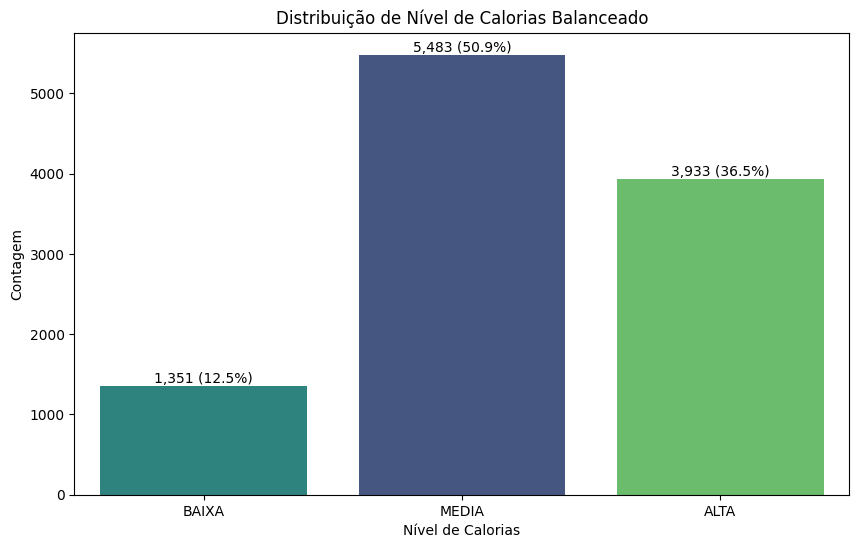

In [225]:
plt.figure(figsize=(10, 6))
# gráfico de barras simples
ax = sns.countplot(x='Nivel_Calorias', data=dafr_Refeicao, hue='Nivel_Calorias', palette='viridis', legend=False, order=['BAIXA', 'MEDIA', 'ALTA'])
plt.title('Distribuição de Nível de Calorias Balanceado')
plt.xlabel('Nível de Calorias')
plt.ylabel('Contagem')

# Calcular as contagens e porcentagens
total = len(dafr_Refeicao)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.show()

Depois que o campo **Calorias (Kcal)** foi recalculado e os valores do campo **Nivel_Calorias** foi reclassificado os valores ficaram desbalanceados.
Então vou fazer um balanciamento dos com base no atributo **Nivel_Calorias** .

Balanceando o atributo **Níveil de Calorias** do dataframe *dafr_Refeicao*

In [245]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Características separadas (X) e alvo (y) do DataFrame dafr_Refeicao
X = dafr_Refeicao.drop('Nivel_Calorias', axis=1)
y = dafr_Refeicao['Nivel_Calorias']

print("Distribuição original da classe 'Nivel_Calorias':")
print(y.value_counts())

# Determine a quantidade de pessoas da classe majoritária. ('MÉDIA')
# Essa será nossa meta de contagem para o balanceamento.
target_class_count = y.value_counts()['MEDIA']

# Defina a estratégia de amostragem para RandomOverSampler:
# Sobrepor as classes 'low' e 'high' para corresponder à contagem da classe 'medium'.
# 'medium' itself is not included in the strategy, so it will remain at its original count.
sampling_strategy = {
    'BAIXA': target_class_count,
    'ALTA': target_class_count
}

# Inicializar RandomOverSampler
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)

# Aplica sobreposição ao conjunto de dados.
X_resampled, y_resampled = ros.fit_resample(X, y)

print("\nDistribuição da classe após o balanceamento (Oversampling):")
print(pd.Series(y_resampled).value_counts())

# Combine as características reamostradas e o alvo em um novo DataFrame.
dafr_Refeicao = pd.DataFrame(X_resampled, columns=X.columns)
dafr_Refeicao['Nivel_Calorias'] = y_resampled

print("\nNovo DataFrame balanceado 'dafr_Refeicao_balanced' (primeiras 5 linhas):")
display(dafr_Calorias.head())

print("\nDistribuição final de classes no novo DataFrame balanceado:")
print(dafr_Refeicao['Nivel_Calorias'].value_counts())

Distribuição original da classe 'Nivel_Calorias':
Nivel_Calorias
MEDIA    5483
ALTA     3933
BAIXA    1351
Name: count, dtype: int64

Distribuição da classe após o balanceamento (Oversampling):
Nivel_Calorias
MEDIA    5483
BAIXA    5483
ALTA     5483
Name: count, dtype: int64

Novo DataFrame balanceado 'dafr_Refeicao_balanced' (primeiras 5 linhas):


,UF,Idade,Sexo,Refeicao,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias_Totais/Kcal,Nivel_Calorias
0,SC,27,M,ALMOCO,22.5,65.2,13.7,9.9,26.7,600.7,MEDIA
1,CE,70,M,JANTAR,15.9,20.7,16.8,7.6,15.0,372.8,BAIXA
2,MG,48,F,LANCHE,28.3,62.4,14.5,10.8,15.3,576.1,MEDIA
3,RR,67,F,CAFE DA MANHA,23.3,18.6,7.9,17.0,0.2,273.5,BAIXA
4,DF,60,M,JANTAR,30.8,55.1,31.9,12.5,7.2,684.5,MEDIA



Distribuição final de classes no novo DataFrame balanceado:
Nivel_Calorias
MEDIA    5483
BAIXA    5483
ALTA     5483
Name: count, dtype: int64


Distibuição de Níveis de Calorias (BAIXA, MEDIA, ALTA)

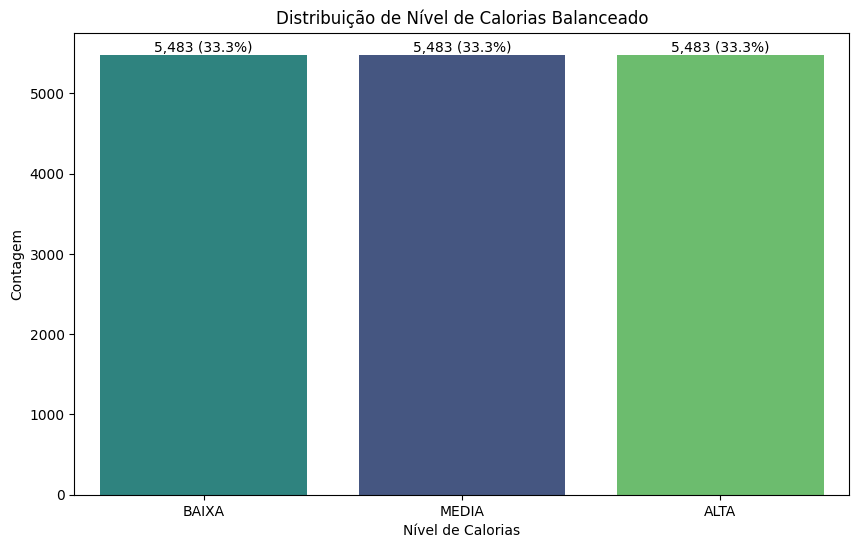

In [246]:
plt.figure(figsize=(10, 6))
# gráfico de barras simples
ax = sns.countplot(x='Nivel_Calorias', data=dafr_Refeicao, hue='Nivel_Calorias', palette='viridis', legend=False, order=['BAIXA', 'MEDIA', 'ALTA'])
plt.title('Distribuição de Nível de Calorias Balanceado')
plt.xlabel('Nível de Calorias')
plt.ylabel('Contagem')

# Calcular as contagens e porcentagens
total = len(dafr_Refeicao)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.show()

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

**1.	Dada os três grupos de Gênero do indivíduo (M- Masculino, F- Feminino ou O- Outros) quem ingere mais calorias - Kcal?**



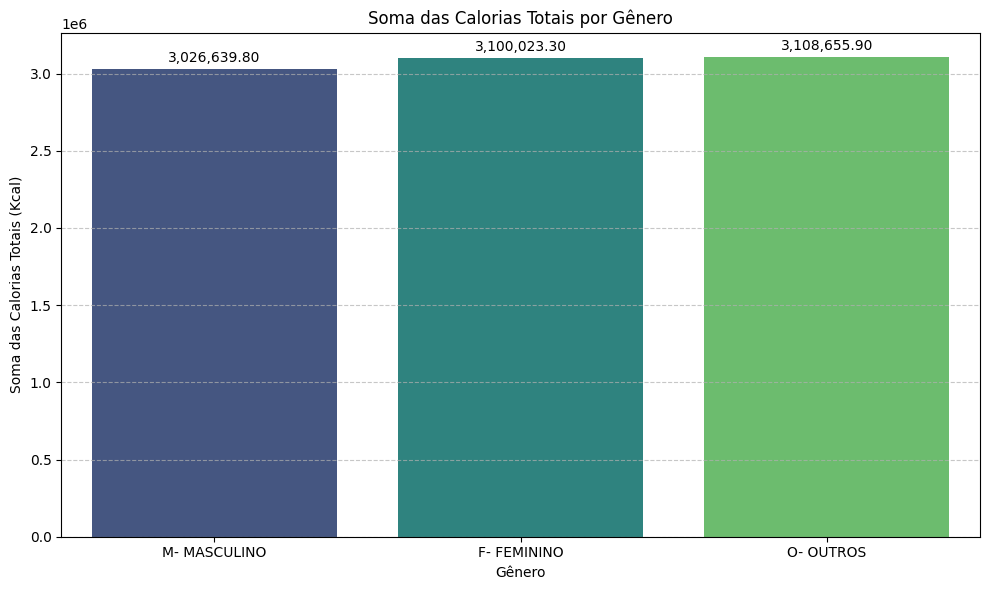

In [247]:
calorias_por_sexo = dafr_Refeicao.groupby('Sexo')['Calorias_Totais/Kcal'].sum().reset_index()

# Mapear os valores de 'Sexo' para os novos rótulos
sexo_mapping = {
    'F': 'F- FEMININO',
    'M': 'M- MASCULINO',
    'O': 'O- OUTROS'
}
calorias_por_sexo['Sexo'] = calorias_por_sexo['Sexo'].map(sexo_mapping)

# Ordenar o DataFrame pela soma de calorias totais (do menor para o maior)
calorias_por_sexo_ordenado = calorias_por_sexo.sort_values(by='Calorias_Totais/Kcal', ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Sexo', y='Calorias_Totais/Kcal', data=calorias_por_sexo_ordenado, hue='Sexo', palette='viridis', legend=False, order=calorias_por_sexo_ordenado['Sexo'])
plt.title('Soma das Calorias Totais por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Soma das Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores no topo das barras com formato de milhares e duas casas decimais
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.2f}', padding=3)

plt.tight_layout()
plt.show()

Aqui agrupo os dados por Sexo e Calorias, calculo o total de calorias para cada um dos grupos de Gênero (M- MASCULINO, F- FEMININO E O- OUTROS), mapeia os rótulos dos gêneros para serem mais descritivos e depois cria um gráfico de barras para visualizar a soma das calorias totais por gênero. O gráfico também é ordenado para facilitar a comparação, mostrando os valores exatos de calorias no topo de cada barra.
**Com isso o Gênero que consome mais Calorias (Kcal) é o OUTROS.**

## Hipótese 2

**2.	Em que Estados Brasileiros se consome mais Calorias - Kcal?**



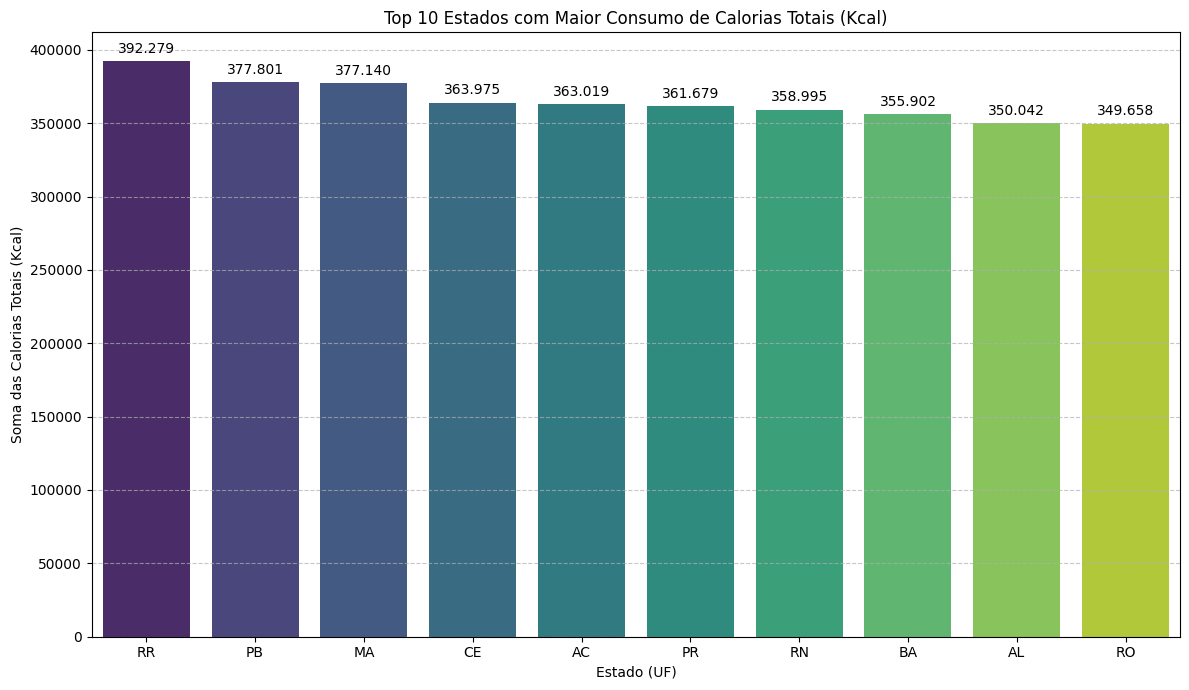

In [248]:
# hipótese 2
# Calculate total calories per UF
calorias_por_uf = dafr_Refeicao.groupby('UF')['Calorias_Totais/Kcal'].sum().reset_index()

# Get the 10 UFs with the highest calorie consumption and sort them in descending order
top_10_uf = calorias_por_uf.nlargest(10, 'Calorias_Totais/Kcal').sort_values(by='Calorias_Totais/Kcal', ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='UF', y='Calorias_Totais/Kcal', data=top_10_uf, hue='UF', palette='viridis', legend=False, order=top_10_uf['UF'])
plt.title('Top 10 Estados com Maior Consumo de Calorias Totais (Kcal)')
plt.xlabel('Estado (UF)')
plt.ylabel('Soma das Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars with thousands separators
for container in ax.containers:
    for p in container.patches:
        ax.annotate(f'{p.get_height():,.0f}'.replace(',', '.'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

Aqui agrupo os dados por Unidade da Federação (UF) e Calorias, calculo o total de calorias para as 10 miores UF, mapeio os rótulos das UFs para serem mais descritivos e depois cria um gráfico de barras para visualizar a soma das calorias totais por UF. O gráfico também é ordenado para facilitar a comparação, mostrando os valores exatos de calorias no topo de cada barra.
**Com isso a UF que consome mais Calorias (Kcal) é Roraima (RR).**

## Hipótese 3

**3.	Quais Macronutrientes (Carboidrato, Proteína, Gordura, fibra, açúcar) são mais consumidos pelos três Gêneros?**



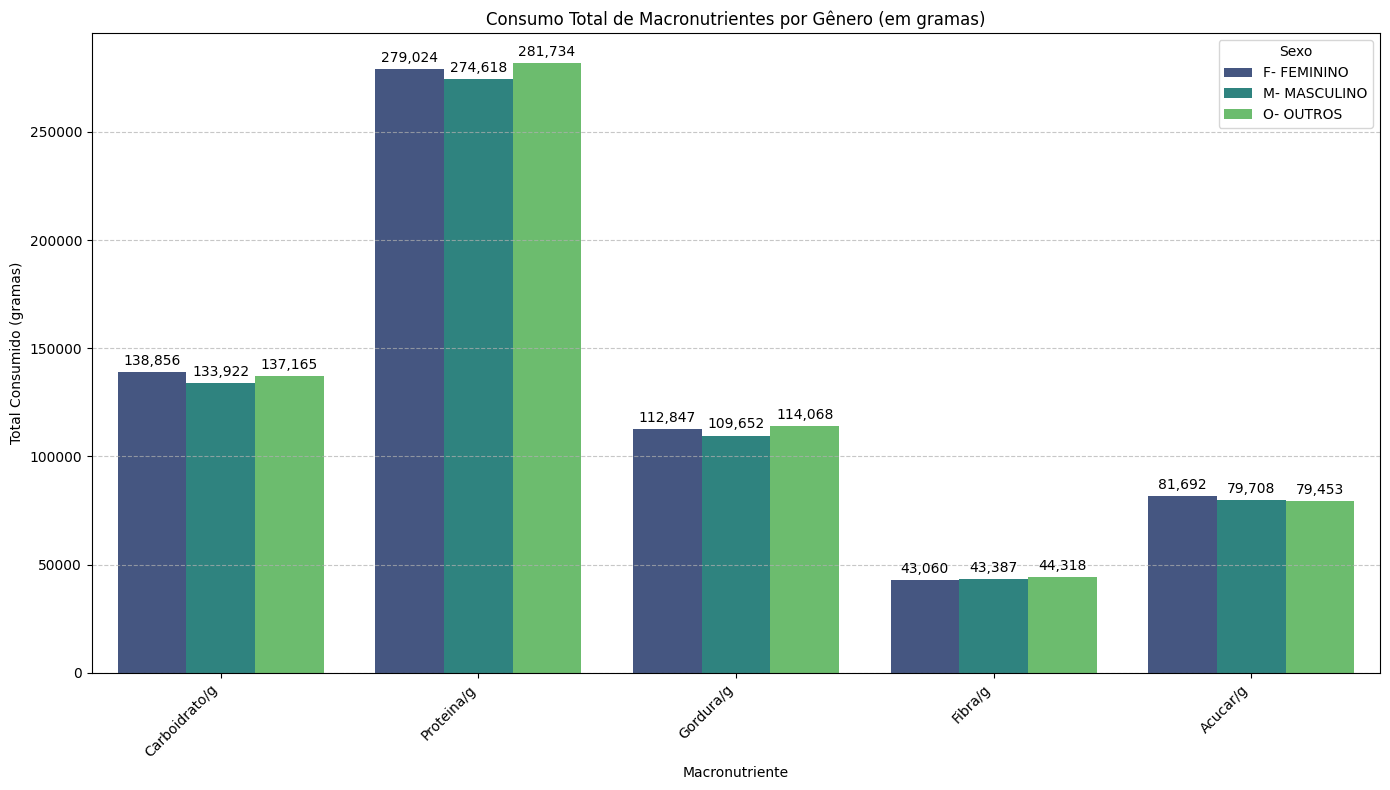

Consumo Total de Macronutrientes por Gênero (em gramas):


,Sexo,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g
0,F- FEMININO,138855.7,279023.5,112846.7,43059.7,81691.7
1,M- MASCULINO,133922.1,274618.4,109652.2,43387.0,79708.5
2,O- OUTROS,137165.2,281733.7,114067.9,44318.0,79453.3


In [249]:
# hipótese 3
# Selecionar as colunas de macronutrientes e 'Sexo'
macronutrientes_cols = ['Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g']
data_macronutrientes = dafr_Refeicao[['Sexo'] + macronutrientes_cols]

# Agrupar por 'Sexo' e somar os macronutrientes
consumo_macronutrientes_por_sexo = data_macronutrientes.groupby('Sexo').sum().reset_index()

# Mapear os valores de 'Sexo' para os novos rótulos
sexo_mapping = {
    'F': 'F- FEMININO',
    'M': 'M- MASCULINO',
    'O': 'O- OUTROS'
}
consumo_macronutrientes_por_sexo['Sexo'] = consumo_macronutrientes_por_sexo['Sexo'].map(sexo_mapping)

# Derreter o DataFrame para o formato 'long' para facilitar a plotagem com seaborn
consumo_long = consumo_macronutrientes_por_sexo.melt(id_vars='Sexo', var_name='Macronutriente', value_name='Total_Consumido_g')

plt.figure(figsize=(14, 8))
ax = sns.barplot(x='Macronutriente', y='Total_Consumido_g', hue='Sexo', data=consumo_long, palette='viridis')
plt.title('Consumo Total de Macronutrientes por Gênero (em gramas)')
plt.xlabel('Macronutriente')
plt.ylabel('Total Consumido (gramas)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores no topo das barras com formato de milhares e duas casas decimais
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Consumo Total de Macronutrientes por Gênero (em gramas):")
display(consumo_macronutrientes_por_sexo)


Aqui calculo e apresento visualmente qual dos grupos de gênero (**Masculino**, **Feminino** ou **Outros**) ingere a maior quantidade de calorias totais.

**A resposta é a Proteína.**

## Hipótese 4

**4.	Dados o Gênero do indivíduo e os alimentos ingeridos é possível identificar em que nível de Calorias eles estão divididos?**


Distribuição do Nível de Calorias por Gênero:


Nivel_Calorias,ALTA,BAIXA,MEDIA
Sexo,,,
F,1870,1738,1864
M,1780,1780,1852
O,1833,1965,1767


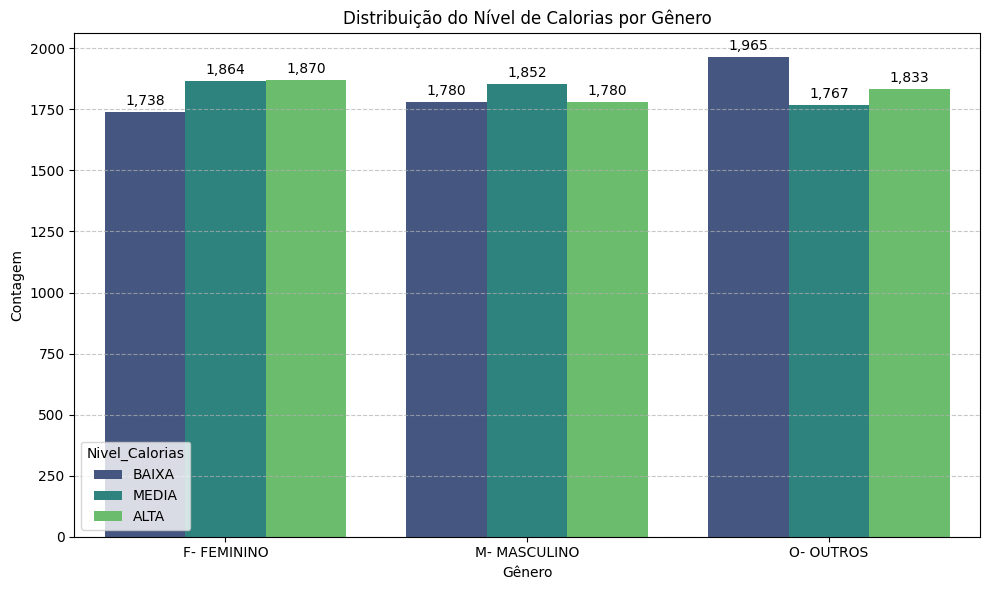

In [250]:
# hipótese 4

# Gerar a tabela de frequência cruzada entre 'Sexo' e 'Nivel_Calorias'
crosstab_sexo_nivel = pd.crosstab(dafr_Refeicao['Sexo'], dafr_Refeicao['Nivel_Calorias'])

print("Distribuição do Nível de Calorias por Gênero:")
display(crosstab_sexo_nivel)

# Mapear os valores de 'Sexo' para os novos rótulos
sexo_mapping = {
    'F': 'F- FEMININO',
    'M': 'M- MASCULINO',
    'O': 'O- OUTROS'
}
dafr_Refeicao_mapped = dafr_Refeicao.copy()
dafr_Refeicao_mapped['Sexo'] = dafr_Refeicao_mapped['Sexo'].map(sexo_mapping)

plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Sexo', hue='Nivel_Calorias', data=dafr_Refeicao_mapped, palette='viridis', order=['F- FEMININO', 'M- MASCULINO', 'O- OUTROS'], hue_order=['BAIXA', 'MEDIA', 'ALTA'])
plt.title('Distribuição do Nível de Calorias por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores no topo das barras
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.tight_layout()
plt.show()

Aqui calculo como os diferentes níveis de calorias se distribuem entre os gêneros, ajudando a responder se é possível identificar em que nível de calorias os indivíduos estão divididos com base no gênero e nos Níveis de Calorias ingeridos.

**A resposta é Sim.**

## Hipótese 5

**5.	Que faixa etárias se consome mais carboidrato?**

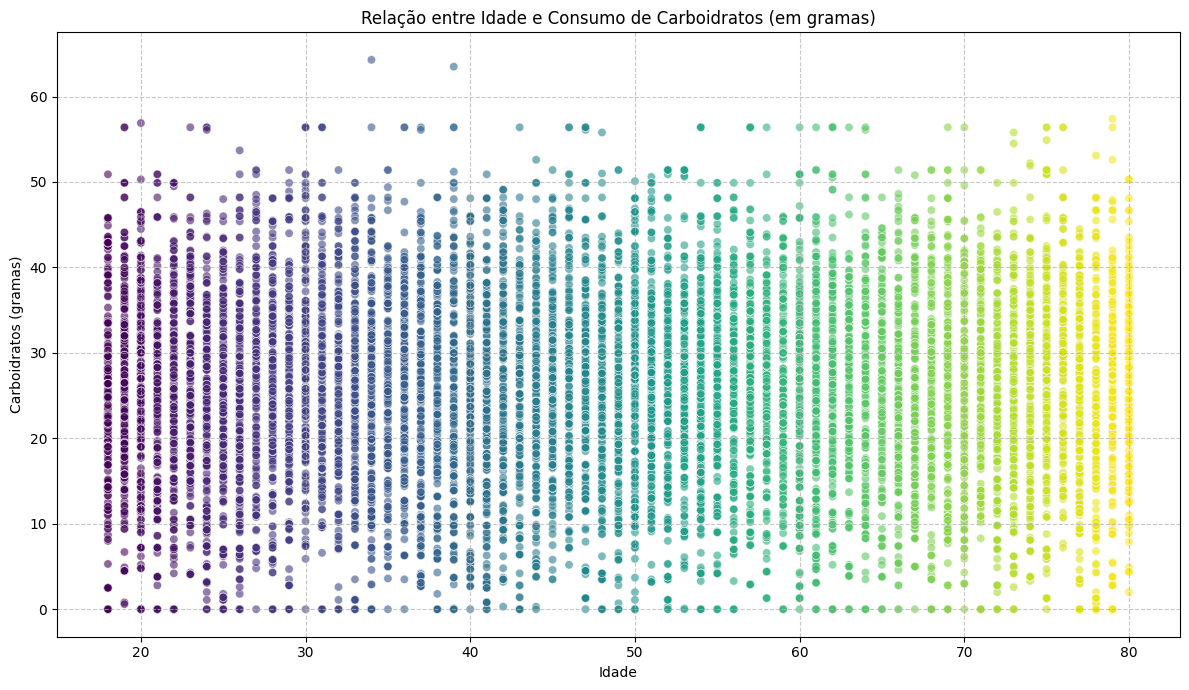

Estatísticas descritivas do consumo de Carboidratos por Idade:


,mean,median,std,min,max
Idade,,,,,
18,24.291078,22.9,10.401345,0.0,50.9
19,26.355636,26.0,9.988515,0.6,56.4
20,25.731987,27.0,10.910094,0.0,56.9
21,22.246591,24.4,11.441868,0.0,50.9
22,23.841107,24.4,11.050255,0.0,49.9


In [251]:
# hipótese 5

plt.figure(figsize=(12, 7))
sns.scatterplot(x='Idade', y='Carboidrato/g', data=dafr_Refeicao, alpha=0.6, hue='Idade', palette='viridis', legend=False)
plt.title('Relação entre Idade e Consumo de Carboidratos (em gramas)')
plt.xlabel('Idade')
plt.ylabel('Carboidratos (gramas)')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Estatísticas descritivas do consumo de Carboidratos por Idade:")
idade_carboidrato_stats = dafr_Refeicao.groupby('Idade')['Carboidrato/g'].agg(['mean', 'median', 'std', 'min', 'max'])
display(idade_carboidrato_stats.head())

Gerei um gráfico de dispersão para visualizar a relação entre '**Idade**' e '**Carboidrato/g**'. Além disso, inclui algumas estatísticas descritivas para analisar o consumo de carboidratos em diferentes faixas etárias. Isso nos ajudará a identificar que faixas etárias consomem mais carboidratos.

**Então a faixa etária de 20 anos é a que consome mais Carboidrato.**

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As 5 hipóteses levantadas foram validadas e estão descritas abaixo de cada uma delas na sessão Hipótese.
